## Phase 1 — Environment Setup & Data Loading

### 1.1 — Import Libraries

In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import warnings
import os
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Data ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# ── Gradient Boosting ─────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# ── Hyperparameter Optimisation ───────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # suppress per-trial noise

# ── SHAP (Model Explainability) ───────────────────────────────────────────────
import shap

# ── Display config ────────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Libraries imported successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   xgboost {xgb.__version__}")
print(f"   lightgbm {lgb.__version__}")
print(f"   optuna  {optuna.__version__}")
print(f"   shap    {shap.__version__}")

✅ Libraries imported successfully
   pandas  2.2.3
   numpy   2.1.3
   xgboost 3.2.0
   lightgbm 4.6.0
   optuna  4.9.0
   shap    0.52.0


### 1.2 — File Paths

In [2]:
# ── Resolve paths relative to this notebook ───────────────────────────────────
ROOT = Path(".")                                      # SpotterAssignment/
DATA = ROOT / "data"

TRAIN_PATH       = DATA / "train-test.csv"
VALIDATION_PATH  = DATA / "validation.csv"
DECEMBER_PATH    = DATA / "december-chart-inputs.csv"
TEMPLATE_PATH    = DATA / "validation-predictions-template.csv"

OUTPUT_PREDICTIONS = ROOT / "validation_predictions.csv"  # final submission file

# ── Verify every input file exists ────────────────────────────────────────────
all_paths = {
    "train-test.csv": TRAIN_PATH,
    "validation.csv": VALIDATION_PATH,
    "december-chart-inputs.csv": DECEMBER_PATH,
    "validation-predictions-template.csv": TEMPLATE_PATH,
}

print("File existence check:")
all_ok = True
for name, path in all_paths.items():
    exists = path.is_file()
    size_mb = path.stat().st_size / 1e6 if exists else 0
    status = "Present" if exists else "Missing"
    print(f"   {status}  {name:<45}  {size_mb:.2f} MB")
    if not exists:
        all_ok = False

if all_ok:
    print("All input files present.")
else:
    raise FileNotFoundError("One or more required input files are missing. Check the paths above.")

File existence check:
   Present  train-test.csv                                 5.96 MB
   Present  validation.csv                                 1.39 MB
   Present  december-chart-inputs.csv                      0.00 MB
   Present  validation-predictions-template.csv            0.13 MB
All input files present.


### 1.3 — Load CSVs & Parse Dates

In [3]:
# ── Load all datasets ─────────────────────────────────────────────────────────
df_train    = pd.read_csv(TRAIN_PATH,      parse_dates=["date"])
df_val      = pd.read_csv(VALIDATION_PATH, parse_dates=["date"])
df_dec      = pd.read_csv(DECEMBER_PATH,   parse_dates=["date"])
df_template = pd.read_csv(TEMPLATE_PATH)

print("All CSVs loaded.")

All CSVs loaded.


### 1.4 — Sanity Checks

In [4]:

def dataset_summary(df: pd.DataFrame, name: str) -> None:
    print("=" * 72)
    print(f" {name}")
    print("=" * 72)
    print(f"  Shape   : {df.shape[0]:,} rows , {df.shape[1]} columns")

    # Date range (if a date column exists)
    date_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    for dc in date_cols:
        print(f"  {dc:<10}: {df[dc].min().date()}  →  {df[dc].max().date()}")


    info = pd.DataFrame({
        "dtype"   : df.dtypes.astype(str),
        "non_null": df.notnull().sum(),
        "nulls"   : df.isnull().sum(),
        "null_%"  : (df.isnull().mean() * 100).round(2),
        "n_unique": df.nunique(),
        "sample"  : df.iloc[0].astype(str),
    })
    print()
    print(info.to_string())
    print()


dataset_summary(df_train,    "TRAIN  (train-test.csv)")
dataset_summary(df_val,      "VALIDATION  (validation.csv)")
dataset_summary(df_dec,      "DECEMBER CHART  (december-chart-inputs.csv)")
dataset_summary(df_template, "TEMPLATE  (validation-predictions-template.csv)")

 TRAIN  (train-test.csv)
  Shape   : 48,000 rows , 14 columns
  date      : 2025-01-01  →  2025-10-31

                       dtype  non_null  nulls  null_%  n_unique               sample
load_id               object     48000      0  0.0000     48000            TR-000001
pickup                object     48000      0  0.0000        64             Richmond
delivery              object     48000      0  0.0000        64            Baltimore
pickup_lat           float64     48000      0  0.0000        64             38.09122
pickup_lon           float64     48000      0  0.0000        63            -76.78906
delivery_lat         float64     48000      0  0.0000        64             38.16908
delivery_lon         float64     48000      0  0.0000        63            -72.74564
distance             float64     48000      0  0.0000     21204                274.3
equipment             object     48000      0  0.0000         3              Dry Van
weight               float64     47700    300  

In [5]:
# ── Quick target-variable peek ─────────────────────────────────────────────────
print("posted_rate — descriptive statistics")
print("-" * 45)
desc = df_train["posted_rate"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
for stat, val in desc.items():
    print(f"   {stat:<8}: ${val:>10,.2f}")

posted_rate — descriptive statistics
---------------------------------------------
   count   : $ 48,000.00
   mean    : $  2,373.98
   std     : $  1,486.49
   min     : $     57.22
   1%      : $    327.17
   5%      : $    599.74
   25%     : $  1,251.55
   50%     : $  2,030.76
   75%     : $  3,330.75
   95%     : $  4,953.77
   99%     : $  5,972.83
   max     : $ 25,533.00


In [6]:
# ── Missing-value overview across all datasets ────────────────────────────────
def missing_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print(f"  {name}: no missing values ✅")
        return pd.DataFrame()
    result = pd.DataFrame({
        "missing": nulls,
        "pct": (nulls / len(df) * 100).round(2),
    })
    print(f"\n  {name} — missing values:")
    print(result.to_string())
    return result

print("🔍  Missing-value audit")
print("=" * 45)
missing_summary(df_train,    "TRAIN")
missing_summary(df_val,      "VALIDATION")
missing_summary(df_dec,      "DECEMBER")
missing_summary(df_template, "TEMPLATE")

🔍  Missing-value audit

  TRAIN — missing values:
              missing    pct
weight            300 0.6200
market_index      374 0.7800

  VALIDATION — missing values:
              missing    pct
weight            165 1.3800
market_index      249 2.0800

  DECEMBER — missing values:
                missing      pct
predicted_rate       31 100.0000

  TEMPLATE — missing values:
                missing      pct
predicted_rate    12000 100.0000


,missing,pct
predicted_rate,12000,100.0000


In [7]:
# ── Category counts ───────────────────────────────────────────────────────────
print("Equipment types in TRAIN:")
print(df_train["equipment"].value_counts().to_string())

print("\nEquipment types in VALIDATION:")
print(df_val["equipment"].value_counts().to_string())

print(f"\nUnique pickup  cities — train: {df_train['pickup'].nunique():>3}  |  val: {df_val['pickup'].nunique():>3}")
print(f"Unique delivery cities — train: {df_train['delivery'].nunique():>3}  |  val: {df_val['delivery'].nunique():>3}")

# New cities in validation not seen in training?
new_pickup   = set(df_val["pickup"])   - set(df_train["pickup"])
new_delivery = set(df_val["delivery"]) - set(df_train["delivery"])
print(f"New pickup cities in validation not in train   : {new_pickup  if new_pickup   else 'None'}")
print(f"New delivery cities in validation not in train : {new_delivery if new_delivery else 'None'}")

Equipment types in TRAIN:
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753

Equipment types in VALIDATION:
equipment
Dry Van    6780
Reefer     3051
Flatbed    2169

Unique pickup  cities — train:  64  |  val:  72
Unique delivery cities — train:  64  |  val:  72
New pickup cities in validation not in train   : {'Jackson', 'Charlotte', 'Allentown', 'Knoxville', 'Laredo', 'San Diego', 'Norfolk', 'Chicago'}
New delivery cities in validation not in train : {'Jackson', 'Charlotte', 'Allentown', 'Knoxville', 'Laredo', 'San Diego', 'Norfolk', 'Chicago'}


In [8]:
# ── Date continuity check ─────────────────────────────────────────────────────
print("Date ranges:")
print(f"   Train      : {df_train['date'].min().date()}  →  {df_train['date'].max().date()}")
print(f"   Validation : {df_val['date'].min().date()}  →  {df_val['date'].max().date()}")
print(f"   December   : {df_dec['date'].min().date()}  →  {df_dec['date'].max().date()}")

gap_days = (df_val["date"].min() - df_train["date"].max()).days
print(f"\n   Gap between last train date and first validation date: {gap_days} day(s)")

# Check for duplicated load_ids within each file
print("\nDuplicate load_id check:")
for name, df in [("TRAIN", df_train), ("VALIDATION", df_val)]:
    dup_count = df["load_id"].duplicated().sum()
    status = "None" if dup_count == 0 else f"{dup_count} duplicates!"
    print(f"   {name:<12}: {status}")

Date ranges:
   Train      : 2025-01-01  →  2025-10-31
   Validation : 2025-11-01  →  2025-12-31
   December   : 2025-12-01  →  2025-12-31

   Gap between last train date and first validation date: 1 day(s)

Duplicate load_id check:
   TRAIN       : None
   VALIDATION  : None


In [9]:
# ── Template vs Validation alignment ─────────────────────────────────────────
print("Template vs Validation alignment:")
template_ids = set(df_template["load_id"])
val_ids      = set(df_val["load_id"])

missing_in_template = val_ids - template_ids
extra_in_template   = template_ids - val_ids

print(f"   Template rows : {len(df_template):,}")
print(f"   Validation IDs: {len(df_val):,}")
print(f"   IDs in val but not template : {len(missing_in_template)}  {'✅' if not missing_in_template else '❌'}")
print(f"   IDs in template but not val : {len(extra_in_template)}   {'✅' if not extra_in_template   else '❌'}")

print("\n📋  December chart columns:")
print(f"   {list(df_dec.columns)}")
print(f"   Predicted_rate filled: {df_dec['predicted_rate'].notnull().sum()} / {len(df_dec)}")

Template vs Validation alignment:
   Template rows : 12,000
   Validation IDs: 12,000
   IDs in val but not template : 0  ✅
   IDs in template but not val : 0   ✅

📋  December chart columns:
   ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
   Predicted_rate filled: 0 / 31


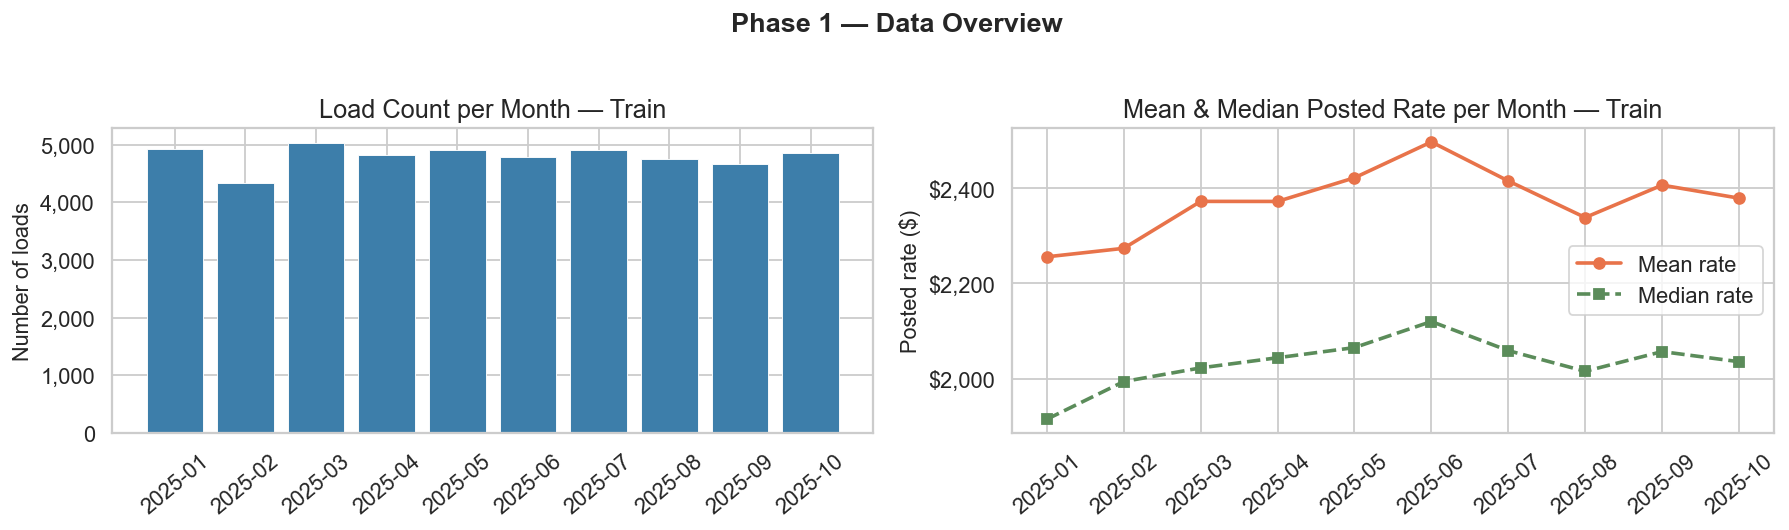

Phase 1 overview chart saved → phase1_overview.png


In [10]:
# ── Monthly load counts (train) — quick bar chart ─────────────────────────────
monthly = df_train.groupby(df_train["date"].dt.to_period("M"))["posted_rate"].agg(["count", "mean", "median"])
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Load count per month
axes[0].bar(monthly.index, monthly["count"], color="#3D7EAA", edgecolor="white", linewidth=0.5)
axes[0].set_title("Load Count per Month — Train")
axes[0].set_ylabel("Number of loads")
axes[0].tick_params(axis="x", rotation=40)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Mean & median rate per month
axes[1].plot(monthly.index, monthly["mean"],   marker="o", label="Mean rate",   color="#E8734A", linewidth=2)
axes[1].plot(monthly.index, monthly["median"], marker="s", label="Median rate", color="#5B8C5A", linewidth=2, linestyle="--")
axes[1].set_title("Mean & Median Posted Rate per Month — Train")
axes[1].set_ylabel("Posted rate ($)")
axes[1].tick_params(axis="x", rotation=40)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

fig.suptitle("Phase 1 — Data Overview", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("phase1_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Phase 1 overview chart saved → phase1_overview.png")

In [11]:
# ── Final Phase 1 summary ─────────────────────────────────────────────────────
print("" + "=" * 60)
print("PHASE 1 COMPLETE — Environment Setup & Data Loading")
print("=" * 60)
print(f"  Train rows      : {len(df_train):>8,}   (target: posted_rate)")
print(f"  Validation rows : {len(df_val):>8,}   (predict these)")
print(f"  December rows   : {len(df_dec):>8,}   (fixed-route chart)")
print(f"  Template rows   : {len(df_template):>8,}   (output scaffold)")
print()
print("  Key observations:")
print(f"    • Temporal gap: train ends {df_train['date'].max().date()},"
      f" val starts {df_val['date'].min().date()}")
print(f"    • Missing weight      : {df_train['weight'].isnull().sum()} train rows"
      f" / {df_val['weight'].isnull().sum()} val rows")
print(f"    • Missing market_index: {df_train['market_index'].isnull().sum()} train rows"
      f" / {df_val['market_index'].isnull().sum()} val rows")
print(f"    • Equipment types     : {sorted(df_train['equipment'].unique())}")
print(f"    • Target mean/std     : ${df_train['posted_rate'].mean():,.2f} "
      f"/ ${df_train['posted_rate'].std():,.2f}")
print()
print("  Objects available for next phases:")
print("    df_train, df_val, df_dec, df_template")
print("=" * 60)

PHASE 1 COMPLETE — Environment Setup & Data Loading
  Train rows      :   48,000   (target: posted_rate)
  Validation rows :   12,000   (predict these)
  December rows   :       31   (fixed-route chart)
  Template rows   :   12,000   (output scaffold)

  Key observations:
    • Temporal gap: train ends 2025-10-31, val starts 2025-11-01
    • Missing weight      : 300 train rows / 165 val rows
    • Missing market_index: 374 train rows / 249 val rows
    • Equipment types     : ['Dry Van', 'Flatbed', 'Reefer']
    • Target mean/std     : $2,373.98 / $1,486.49

  Objects available for next phases:
    df_train, df_val, df_dec, df_template


## Phase 2 — Exploratory Data Analysis (EDA)

### 2a — Target Distribution (`posted_rate`)

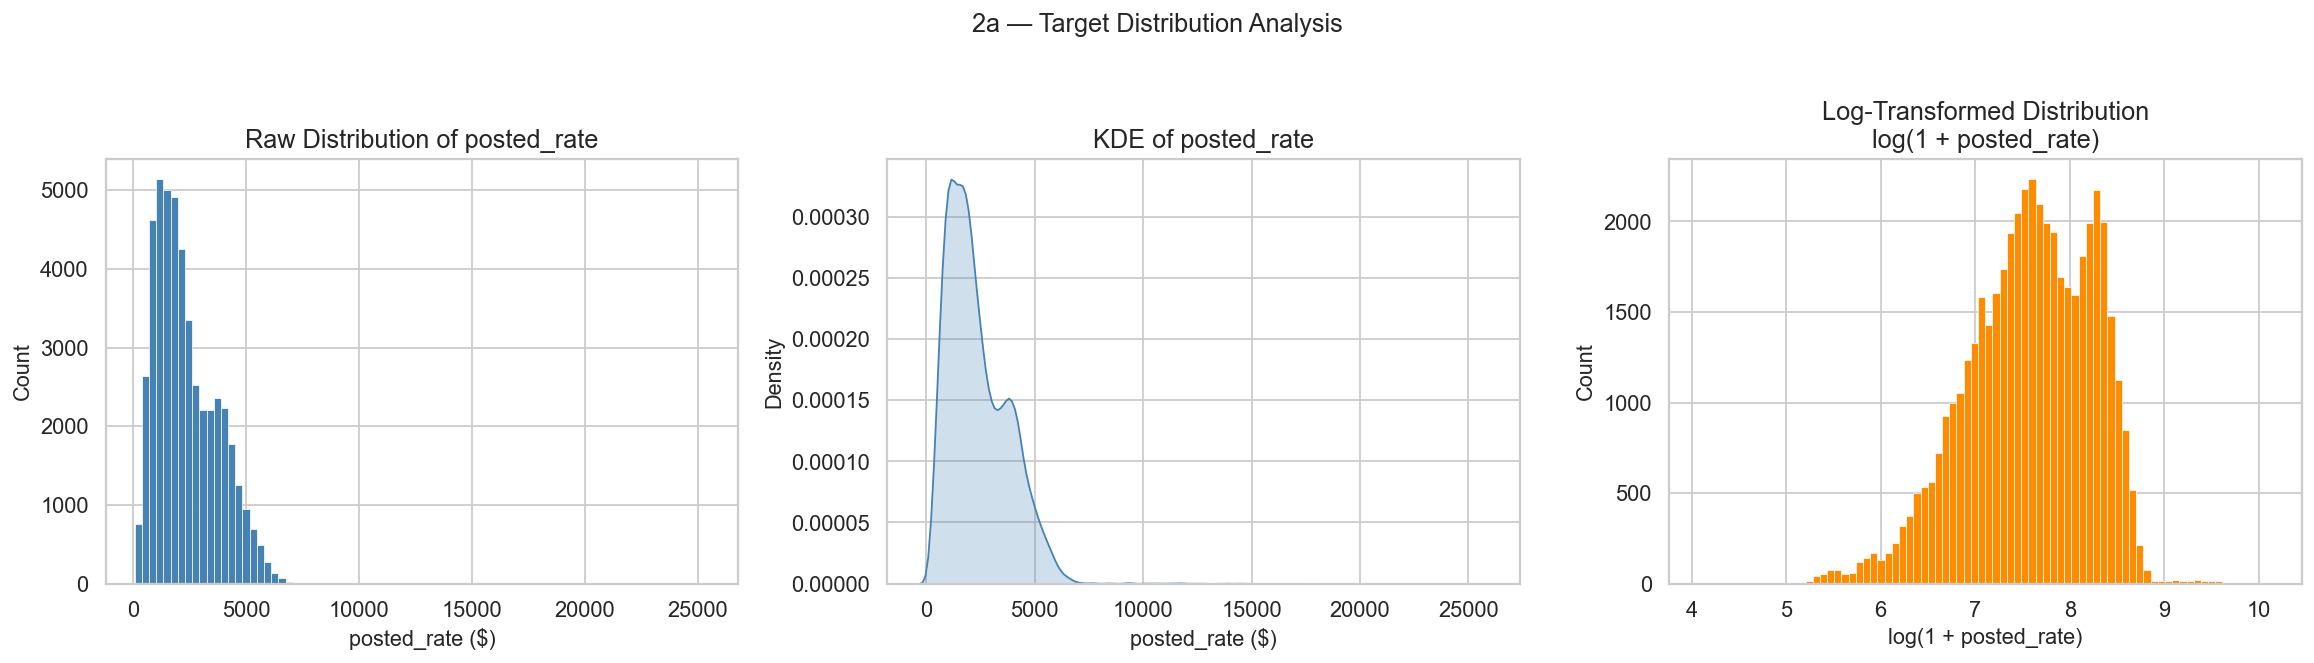

Raw skewness : 1.9024
Log skewness : -0.4889

Decision: right-skewed raw distribution → will model log(posted_rate) to reduce outlier influence.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_train['posted_rate'], bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Raw Distribution of posted_rate')
axes[0].set_xlabel('posted_rate ($)')
axes[0].set_ylabel('Count')

sns.kdeplot(df_train['posted_rate'], ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('KDE of posted_rate')
axes[1].set_xlabel('posted_rate ($)')

log_rate = np.log1p(df_train['posted_rate'])
axes[2].hist(log_rate, bins=80, color='darkorange', edgecolor='white', linewidth=0.4)
axes[2].set_title('Log-Transformed Distribution\nlog(1 + posted_rate)')
axes[2].set_xlabel('log(1 + posted_rate)')
axes[2].set_ylabel('Count')

plt.suptitle('2a — Target Distribution Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_2a_target_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

skewness = df_train['posted_rate'].skew()
log_skewness = log_rate.skew()
print(f'Raw skewness : {skewness:.4f}')
print(f'Log skewness : {log_skewness:.4f}')
print()
print('Decision: right-skewed raw distribution → will model log(posted_rate) to reduce outlier influence.')


### 2b — Missing Value Analysis

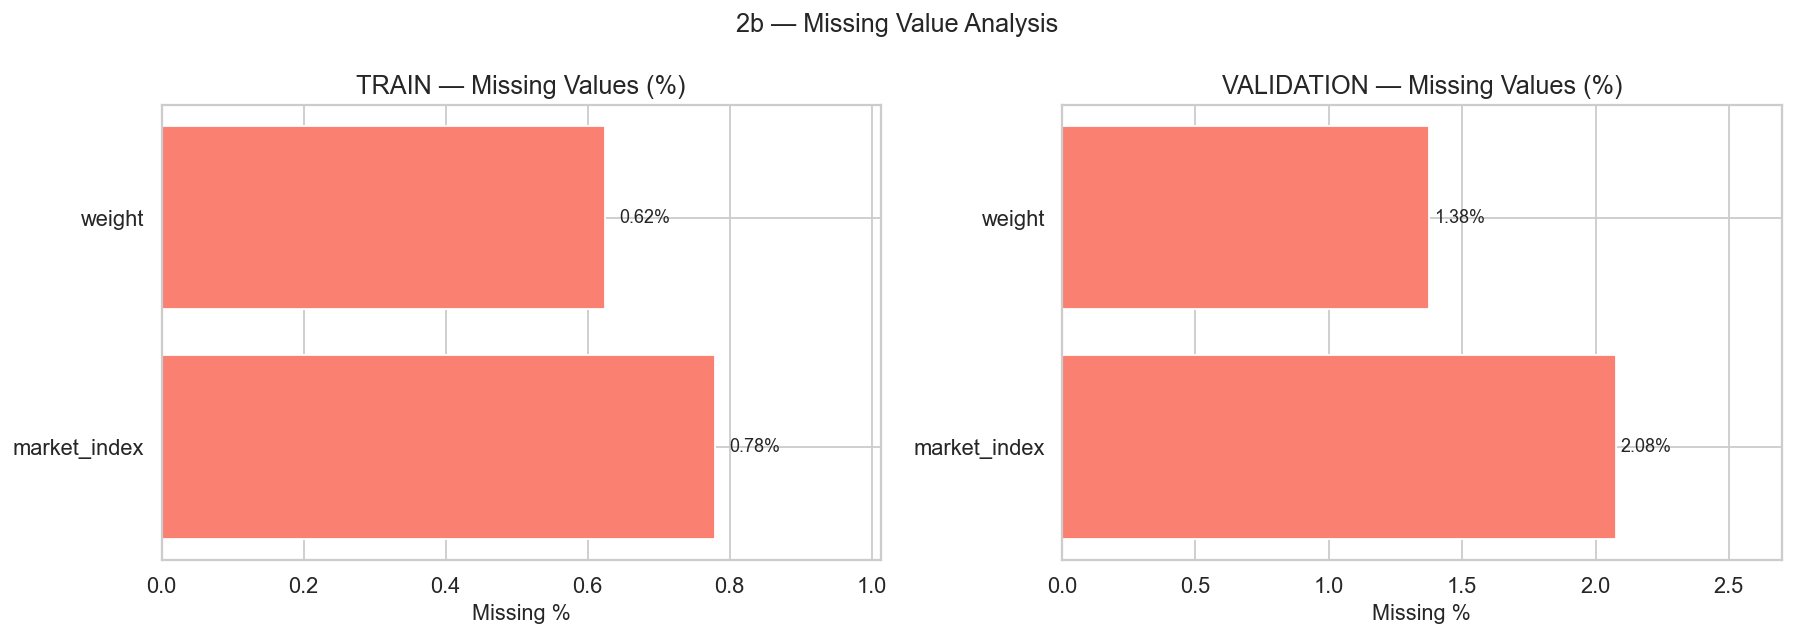

Imputation strategy:
  weight       → median per equipment type (different load types have different weight norms)
  market_index → 7-day rolling mean per date, fallback to global median


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [(df_train, 'TRAIN'), (df_val, 'VALIDATION')]):
    missing_pct = df.isnull().mean() * 100
    missing_df = pd.DataFrame({'column': missing_pct.index, 'missing_pct': missing_pct.values})
    missing_df = missing_df[missing_df['missing_pct'] > 0].sort_values('missing_pct', ascending=False)

    if missing_df.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=12)
        ax.set_title(f'{title} — No Missing Values')
    else:
        bars = ax.barh(missing_df['column'], missing_df['missing_pct'], color='salmon')
        for bar, val in zip(bars, missing_df['missing_pct']):
            ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}%', va='center', fontsize=10)
        ax.set_title(f'{title} — Missing Values (%)')
        ax.set_xlabel('Missing %')
        ax.set_xlim(0, max(missing_df['missing_pct']) * 1.3)

plt.suptitle('2b — Missing Value Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2b_missing_values.png', dpi=130, bbox_inches='tight')
plt.show()

print('Imputation strategy:')
print('  weight       → median per equipment type (different load types have different weight norms)')
print('  market_index → 7-day rolling mean per date, fallback to global median')


### 2c — Feature vs Target Relationships

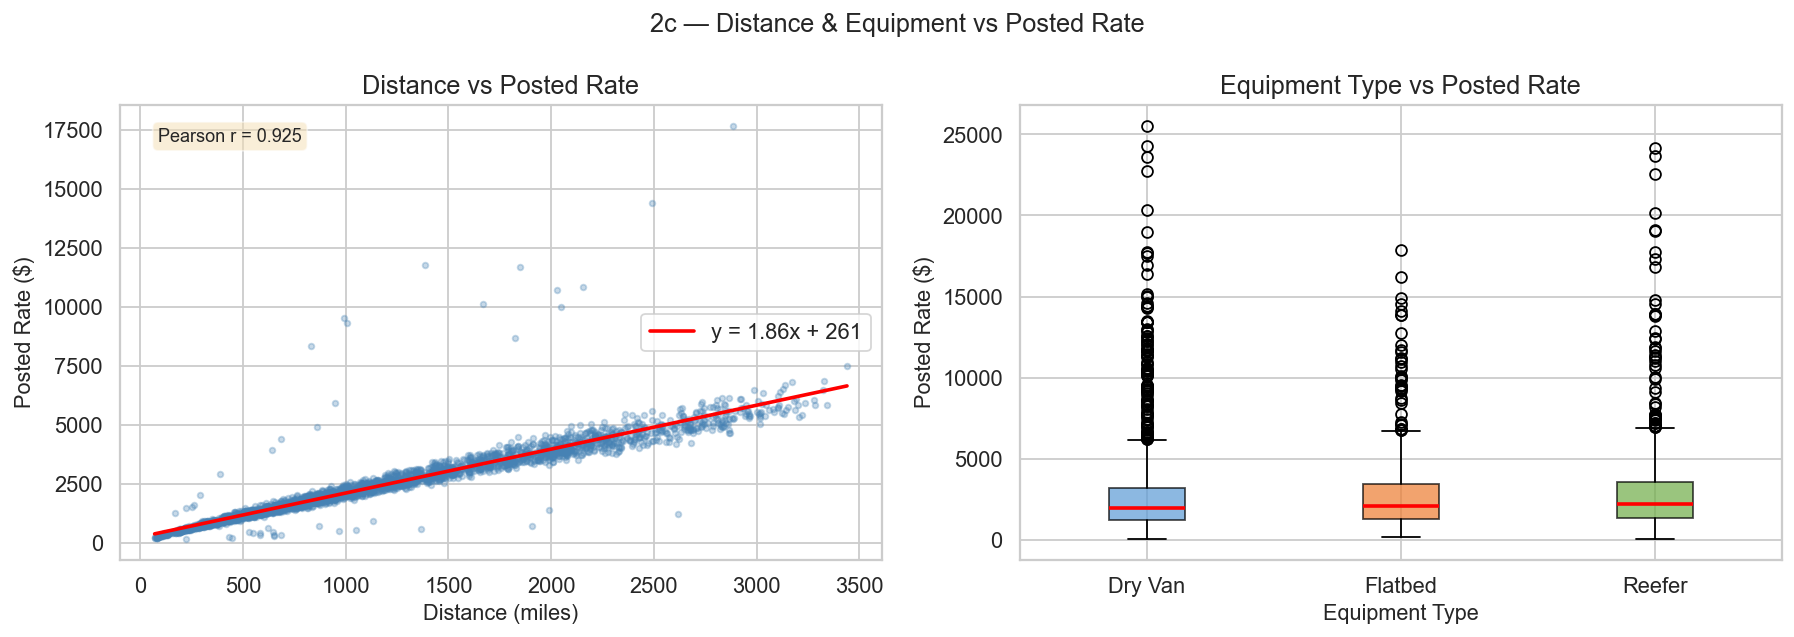

Median posted_rate by equipment:
equipment
Reefer    2196.6700
Flatbed   2076.8100
Dry Van   1953.0350


In [14]:
sample = df_train.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['distance'], sample['posted_rate'], alpha=0.3, s=10, color='steelblue')
m, b = np.polyfit(sample['distance'], sample['posted_rate'], 1)
x_line = np.linspace(sample['distance'].min(), sample['distance'].max(), 200)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'y = {m:.2f}x + {b:.0f}')
axes[0].set_title('Distance vs Posted Rate')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Posted Rate ($)')
axes[0].legend()

corr = sample[['distance', 'posted_rate']].corr().iloc[0, 1]
axes[0].text(0.05, 0.92, f'Pearson r = {corr:.3f}', transform=axes[0].transAxes,
             fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

equipment_order = ['Dry Van', 'Flatbed', 'Reefer']
groups = [df_train[df_train['equipment'] == eq]['posted_rate'].dropna() for eq in equipment_order]
bp = axes[1].boxplot(groups, labels=equipment_order, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
colors = ['#5B9BD5', '#ED7D31', '#70AD47']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Equipment Type vs Posted Rate')
axes[1].set_xlabel('Equipment Type')
axes[1].set_ylabel('Posted Rate ($)')

plt.suptitle('2c — Distance & Equipment vs Posted Rate', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2c_distance_equipment.png', dpi=130, bbox_inches='tight')
plt.show()

print('Median posted_rate by equipment:')
print(df_train.groupby('equipment')['posted_rate'].median().sort_values(ascending=False).to_string())


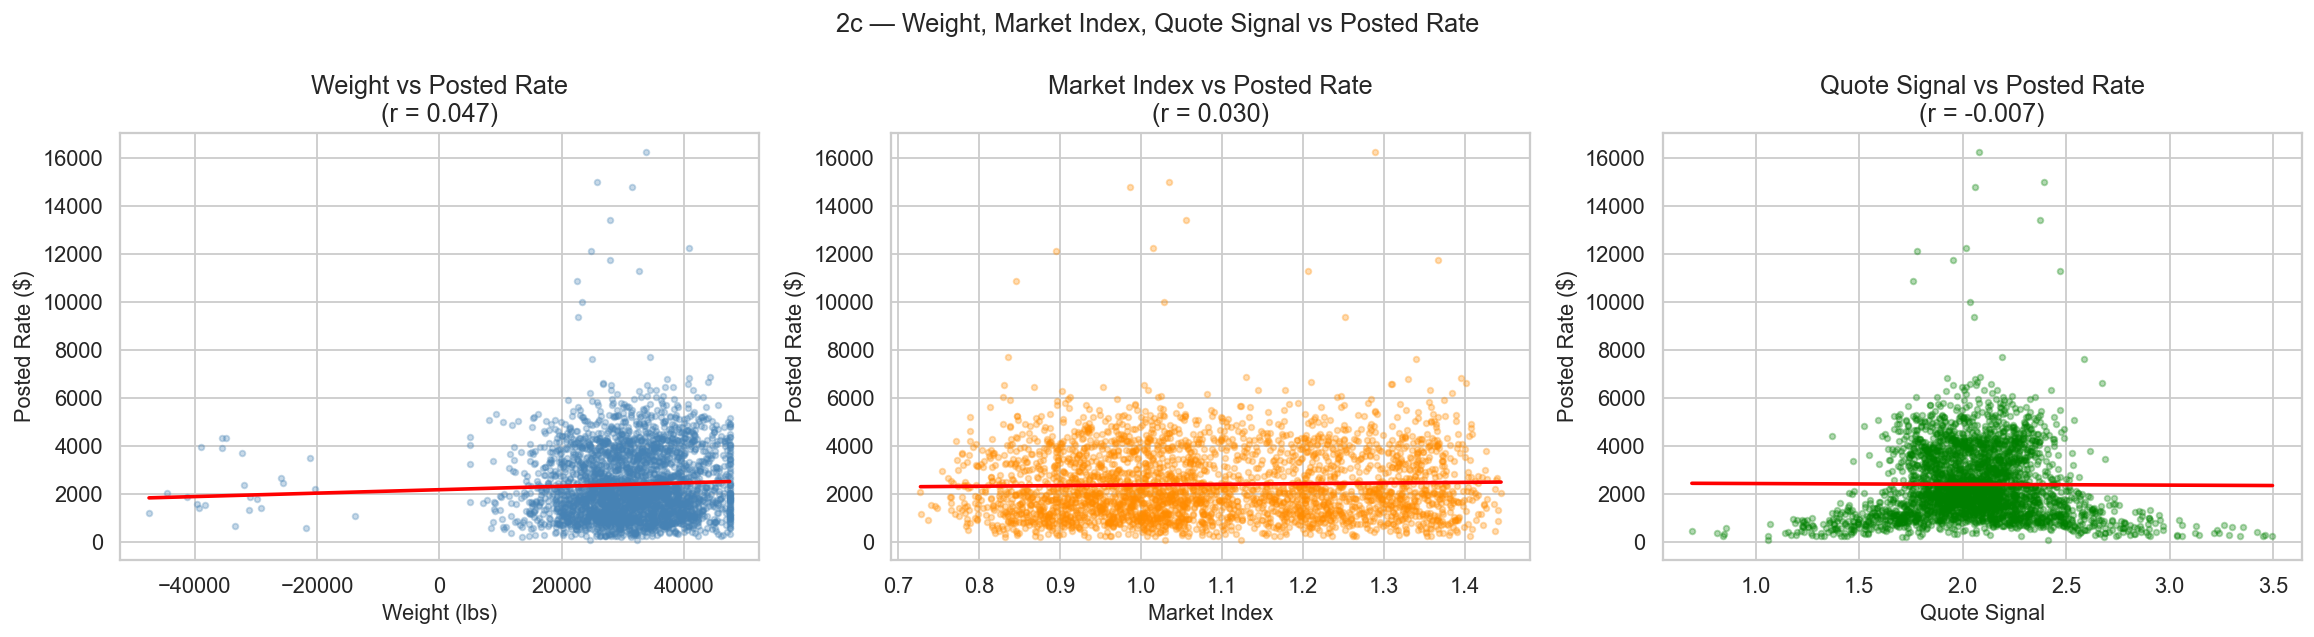

In [15]:
sample = df_train.dropna(subset=['weight', 'market_index']).sample(3000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(sample['weight'], sample['posted_rate'], alpha=0.3, s=10, color='steelblue')
m, b = np.polyfit(sample['weight'], sample['posted_rate'], 1)
x_line = np.linspace(sample['weight'].min(), sample['weight'].max(), 200)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2)
corr = sample[['weight', 'posted_rate']].corr().iloc[0, 1]
axes[0].set_title(f'Weight vs Posted Rate\n(r = {corr:.3f})')
axes[0].set_xlabel('Weight (lbs)')
axes[0].set_ylabel('Posted Rate ($)')

axes[1].scatter(sample['market_index'], sample['posted_rate'], alpha=0.3, s=10, color='darkorange')
m, b = np.polyfit(sample['market_index'], sample['posted_rate'], 1)
x_line = np.linspace(sample['market_index'].min(), sample['market_index'].max(), 200)
axes[1].plot(x_line, m * x_line + b, color='red', linewidth=2)
corr = sample[['market_index', 'posted_rate']].corr().iloc[0, 1]
axes[1].set_title(f'Market Index vs Posted Rate\n(r = {corr:.3f})')
axes[1].set_xlabel('Market Index')
axes[1].set_ylabel('Posted Rate ($)')

axes[2].scatter(sample['quote_signal'], sample['posted_rate'], alpha=0.3, s=10, color='green')
m, b = np.polyfit(sample['quote_signal'], sample['posted_rate'], 1)
x_line = np.linspace(sample['quote_signal'].min(), sample['quote_signal'].max(), 200)
axes[2].plot(x_line, m * x_line + b, color='red', linewidth=2)
corr = sample[['quote_signal', 'posted_rate']].corr().iloc[0, 1]
axes[2].set_title(f'Quote Signal vs Posted Rate\n(r = {corr:.3f})')
axes[2].set_xlabel('Quote Signal')
axes[2].set_ylabel('Posted Rate ($)')

plt.suptitle('2c — Weight, Market Index, Quote Signal vs Posted Rate', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2c_numeric_features.png', dpi=130, bbox_inches='tight')
plt.show()


### 2d — Temporal Patterns

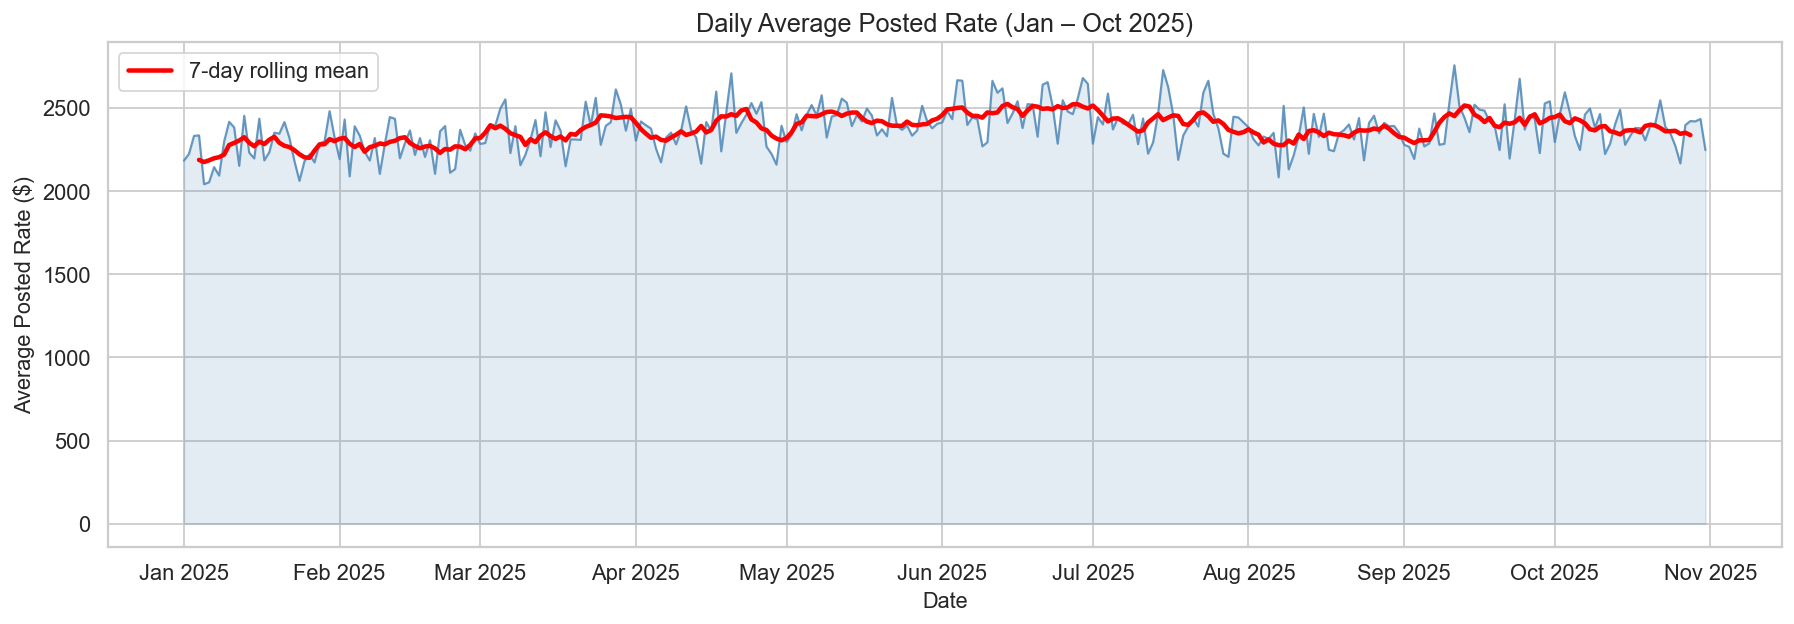

In [16]:
daily = df_train.groupby('date')['posted_rate'].mean().reset_index()
daily.columns = ['date', 'avg_rate']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['date'], daily['avg_rate'], color='steelblue', linewidth=1.2, alpha=0.8)
ax.fill_between(daily['date'], daily['avg_rate'], alpha=0.15, color='steelblue')

rolling_7 = daily['avg_rate'].rolling(7, center=True).mean()
ax.plot(daily['date'], rolling_7, color='red', linewidth=2.5, label='7-day rolling mean')

ax.set_title('Daily Average Posted Rate (Jan – Oct 2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Average Posted Rate ($)')
ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('eda_2d_daily_rate.png', dpi=130, bbox_inches='tight')
plt.show()


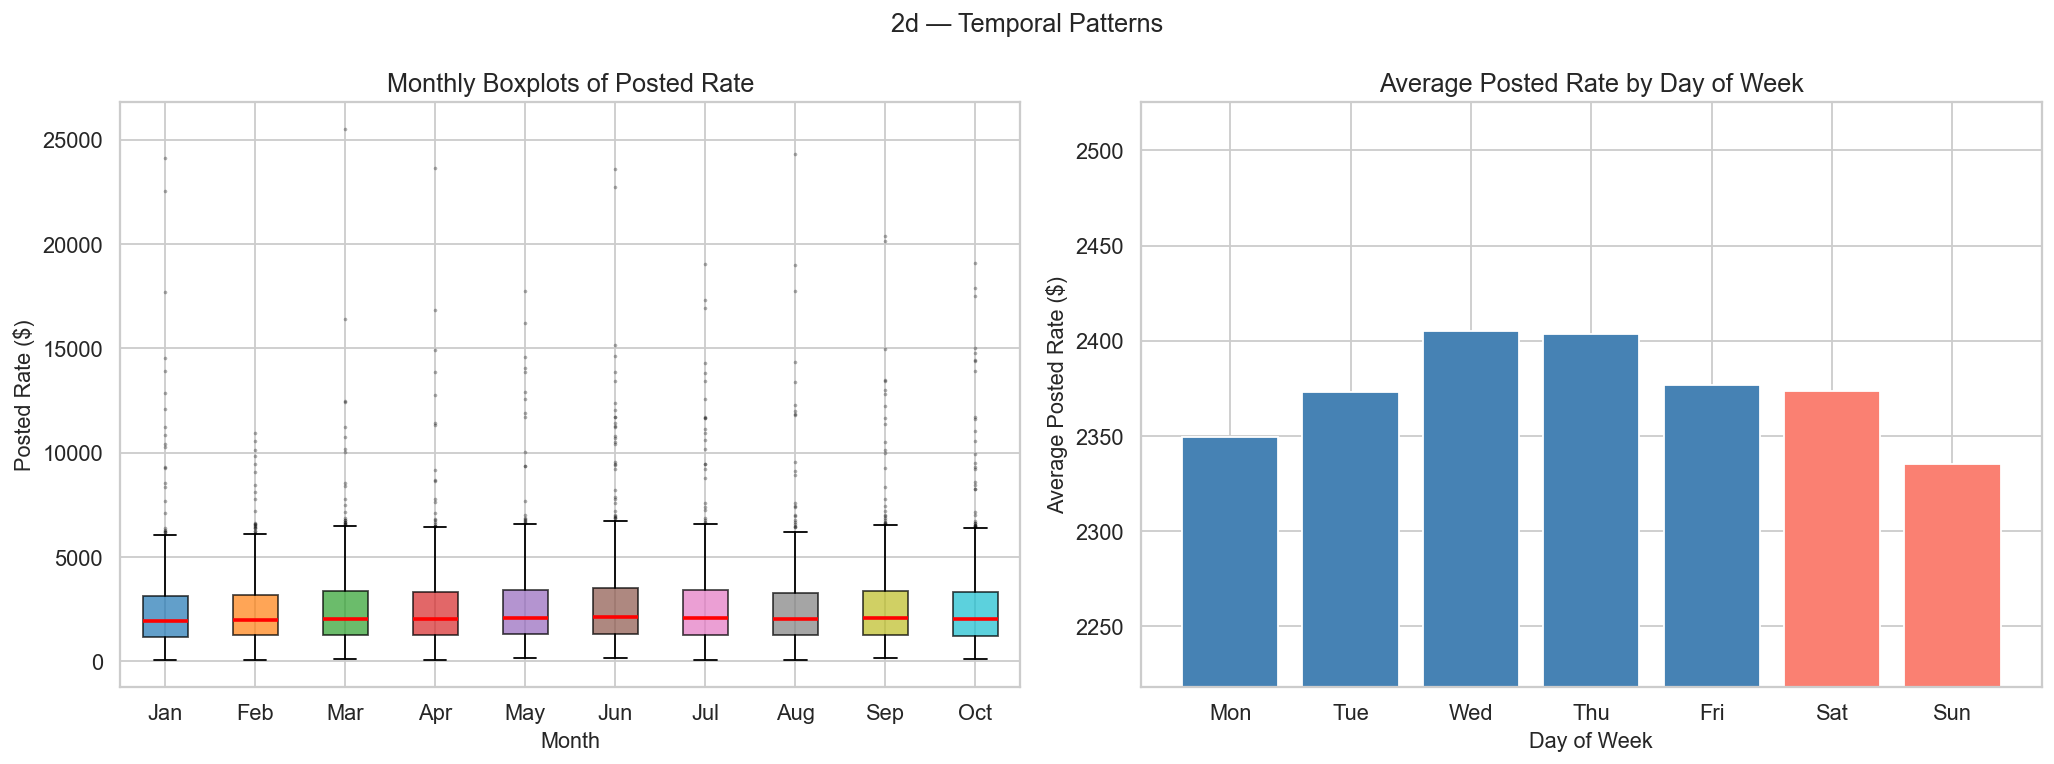

Average rate by day of week:
dow_name
Mon   2349.3087
Tue   2372.8906
Wed   2405.0867
Thu   2403.2656
Fri   2376.8499
Sat   2373.7143
Sun   2335.0732


In [17]:
df_train['month'] = df_train['date'].dt.month
df_train['month_name'] = df_train['date'].dt.strftime('%b')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']
df_train['month_name'] = pd.Categorical(df_train['month_name'], categories=month_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

monthly_data = [df_train[df_train['month_name'] == m]['posted_rate'].dropna() for m in month_order]
bp = axes[0].boxplot(monthly_data, labels=month_order, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='.', markersize=2, alpha=0.3))
colors = plt.cm.tab10.colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Monthly Boxplots of Posted Rate')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Posted Rate ($)')

df_train['dow'] = df_train['date'].dt.dayofweek
df_train['dow_name'] = df_train['date'].dt.strftime('%a')
dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_train['dow_name'] = pd.Categorical(df_train['dow_name'], categories=dow_order, ordered=True)

dow_means = df_train.groupby('dow_name', observed=True)['posted_rate'].mean().reindex(dow_order)
bar_colors = ['steelblue'] * 5 + ['salmon', 'salmon']
axes[1].bar(dow_order, dow_means, color=bar_colors, edgecolor='white')
axes[1].set_title('Average Posted Rate by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Posted Rate ($)')
axes[1].set_ylim(dow_means.min() * 0.95, dow_means.max() * 1.05)

plt.suptitle('2d — Temporal Patterns', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2d_temporal.png', dpi=130, bbox_inches='tight')
plt.show()

print('Average rate by day of week:')
print(dow_means.to_string())


### 2e — Geographic Patterns

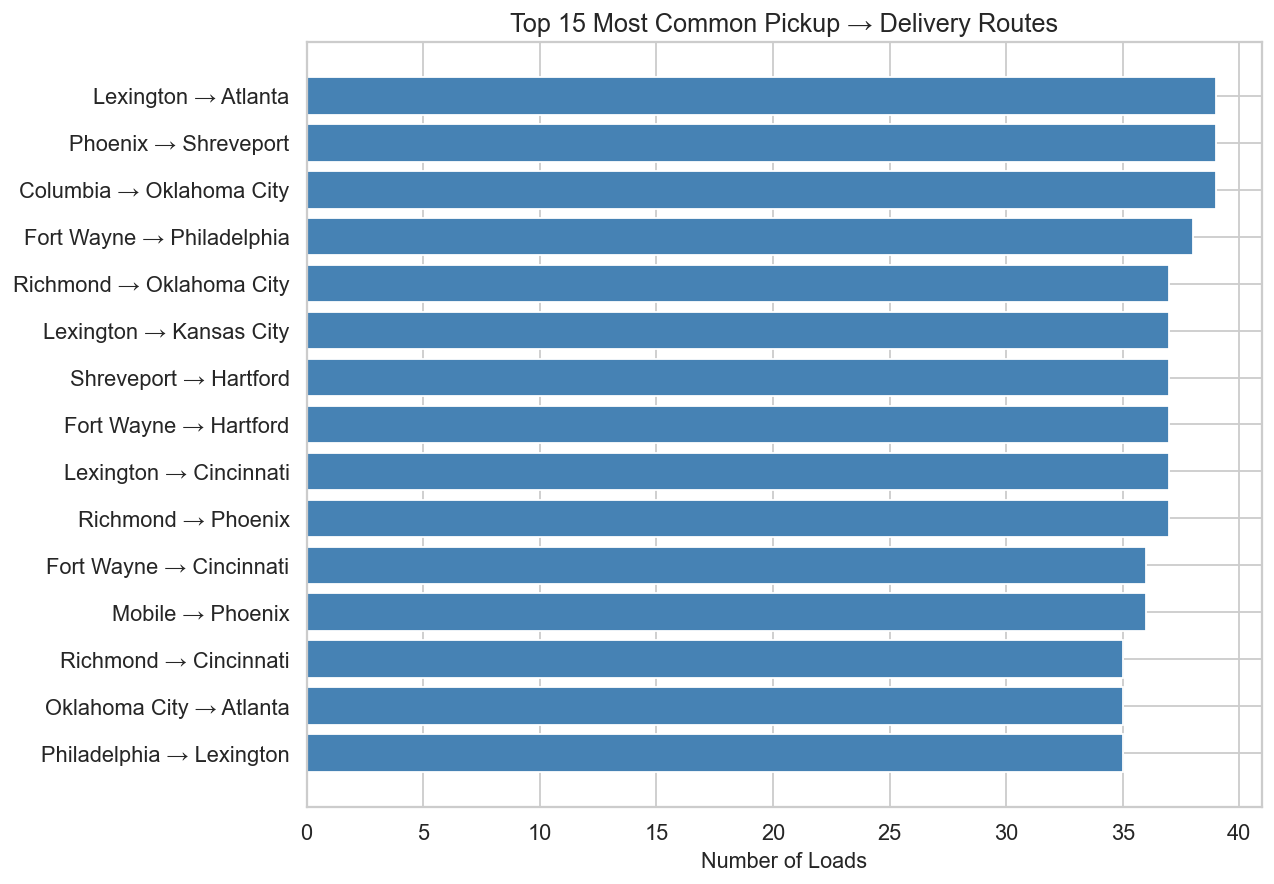

In [18]:
pair_counts = (df_train
               .groupby(['pickup', 'delivery'])
               .size()
               .reset_index(name='count')
               .sort_values('count', ascending=False)
               .head(15))

pair_counts['route'] = pair_counts['pickup'] + ' → ' + pair_counts['delivery']

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pair_counts['route'][::-1], pair_counts['count'][::-1], color='steelblue')
ax.set_title('Top 15 Most Common Pickup → Delivery Routes')
ax.set_xlabel('Number of Loads')
plt.tight_layout()
plt.savefig('eda_2e_top_routes.png', dpi=130, bbox_inches='tight')
plt.show()


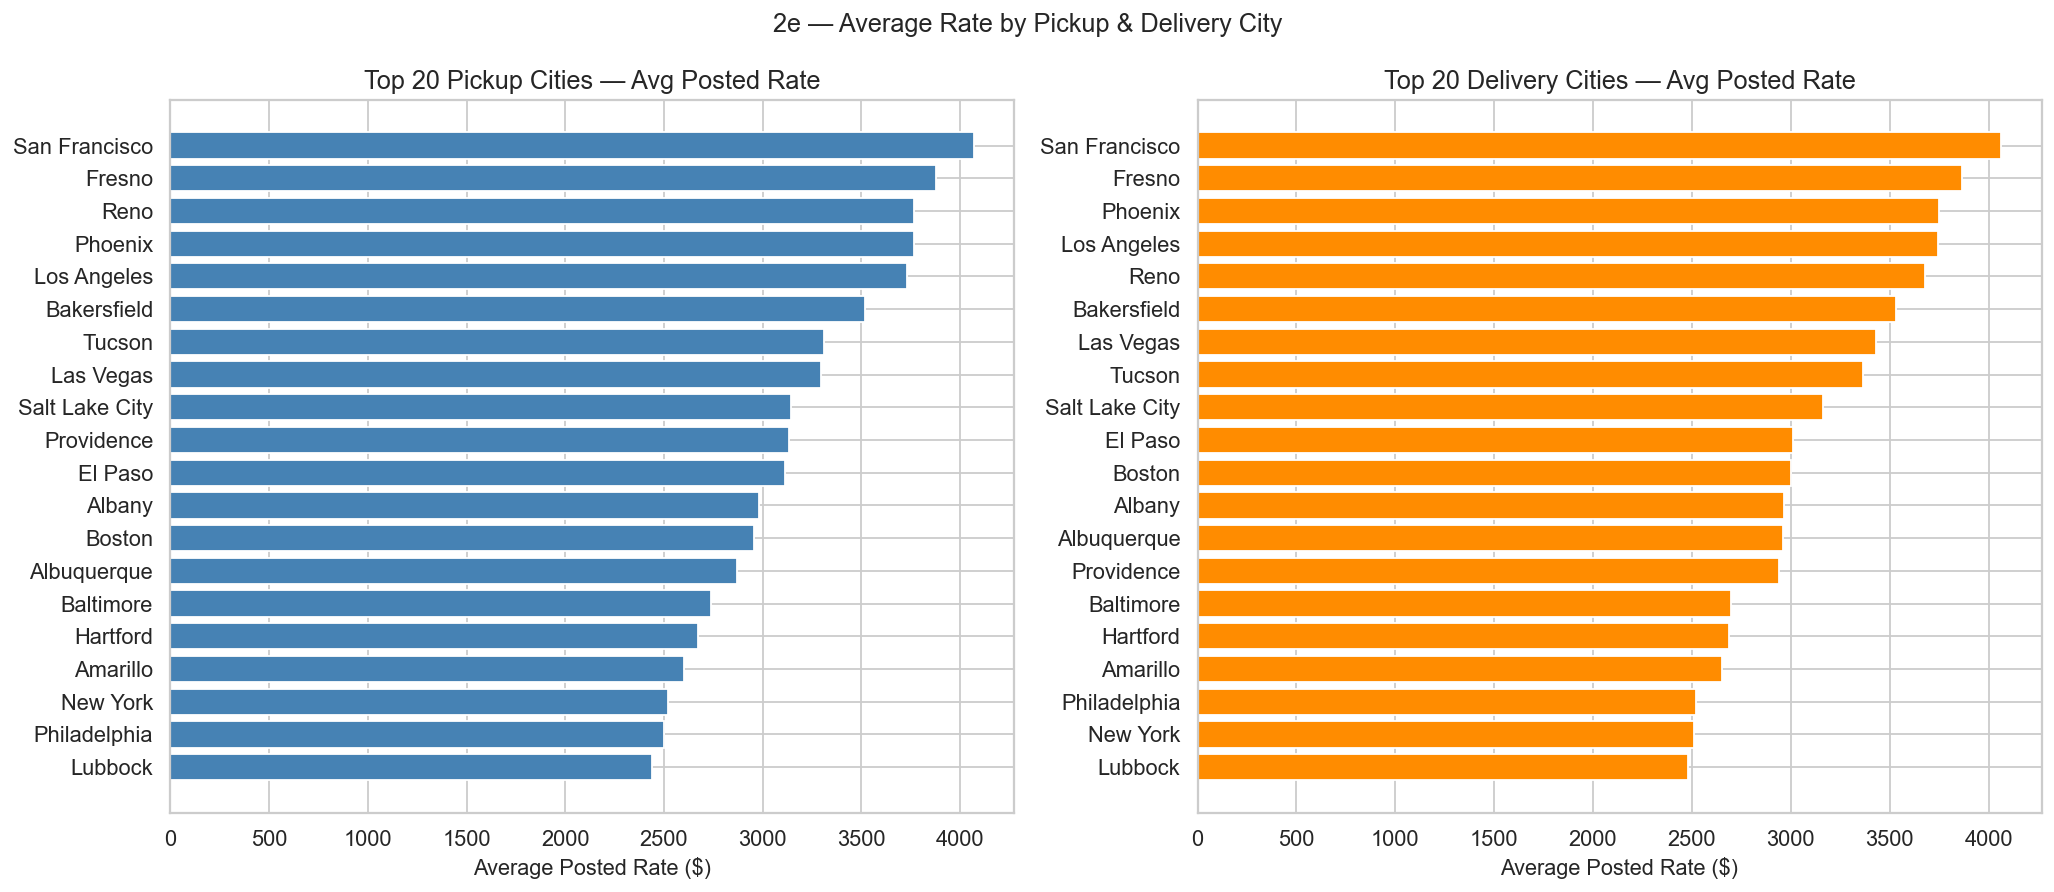

In [19]:
pivot_pickup = (df_train
                .groupby('pickup')['posted_rate']
                .mean()
                .sort_values(ascending=False)
                .head(20))

pivot_delivery = (df_train
                  .groupby('delivery')['posted_rate']
                  .mean()
                  .sort_values(ascending=False)
                  .head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(pivot_pickup.index[::-1], pivot_pickup.values[::-1], color='steelblue')
axes[0].set_title('Top 20 Pickup Cities — Avg Posted Rate')
axes[0].set_xlabel('Average Posted Rate ($)')

axes[1].barh(pivot_delivery.index[::-1], pivot_delivery.values[::-1], color='darkorange')
axes[1].set_title('Top 20 Delivery Cities — Avg Posted Rate')
axes[1].set_xlabel('Average Posted Rate ($)')

plt.suptitle('2e — Average Rate by Pickup & Delivery City', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2e_city_rates.png', dpi=130, bbox_inches='tight')
plt.show()


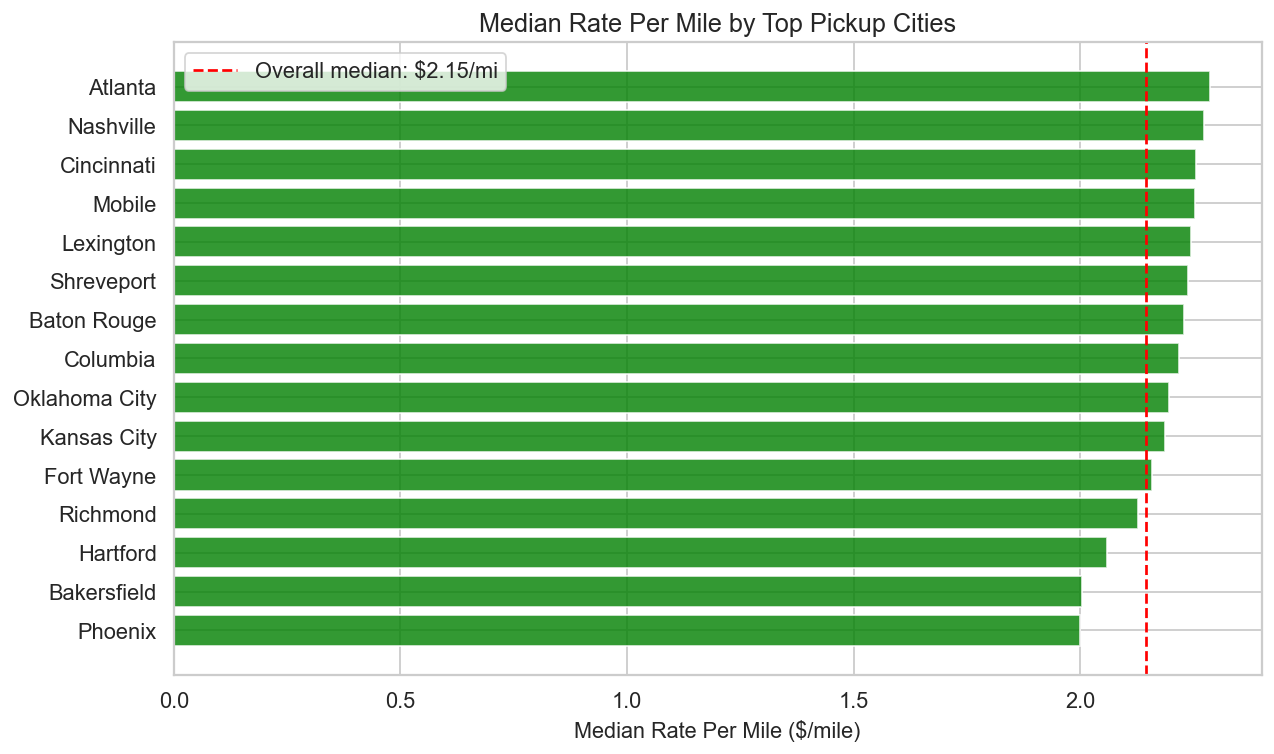

Overall median rate per mile: $2.15
Overall mean   rate per mile: $2.22


In [20]:
df_train['rate_per_mile'] = df_train['posted_rate'] / df_train['distance']

top_pickups = df_train['pickup'].value_counts().head(15).index
rate_per_mile_city = (df_train[df_train['pickup'].isin(top_pickups)]
                      .groupby('pickup')['rate_per_mile']
                      .median()
                      .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rate_per_mile_city.index[::-1], rate_per_mile_city.values[::-1], color='green', alpha=0.8)
ax.set_title('Median Rate Per Mile by Top Pickup Cities')
ax.set_xlabel('Median Rate Per Mile ($/mile)')
ax.axvline(df_train['rate_per_mile'].median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall median: ${df_train["rate_per_mile"].median():.2f}/mi')
ax.legend()
plt.tight_layout()
plt.savefig('eda_2e_rate_per_mile.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Overall median rate per mile: ${df_train["rate_per_mile"].median():.2f}')
print(f'Overall mean   rate per mile: ${df_train["rate_per_mile"].mean():.2f}')


### 2f — Correlation Matrix

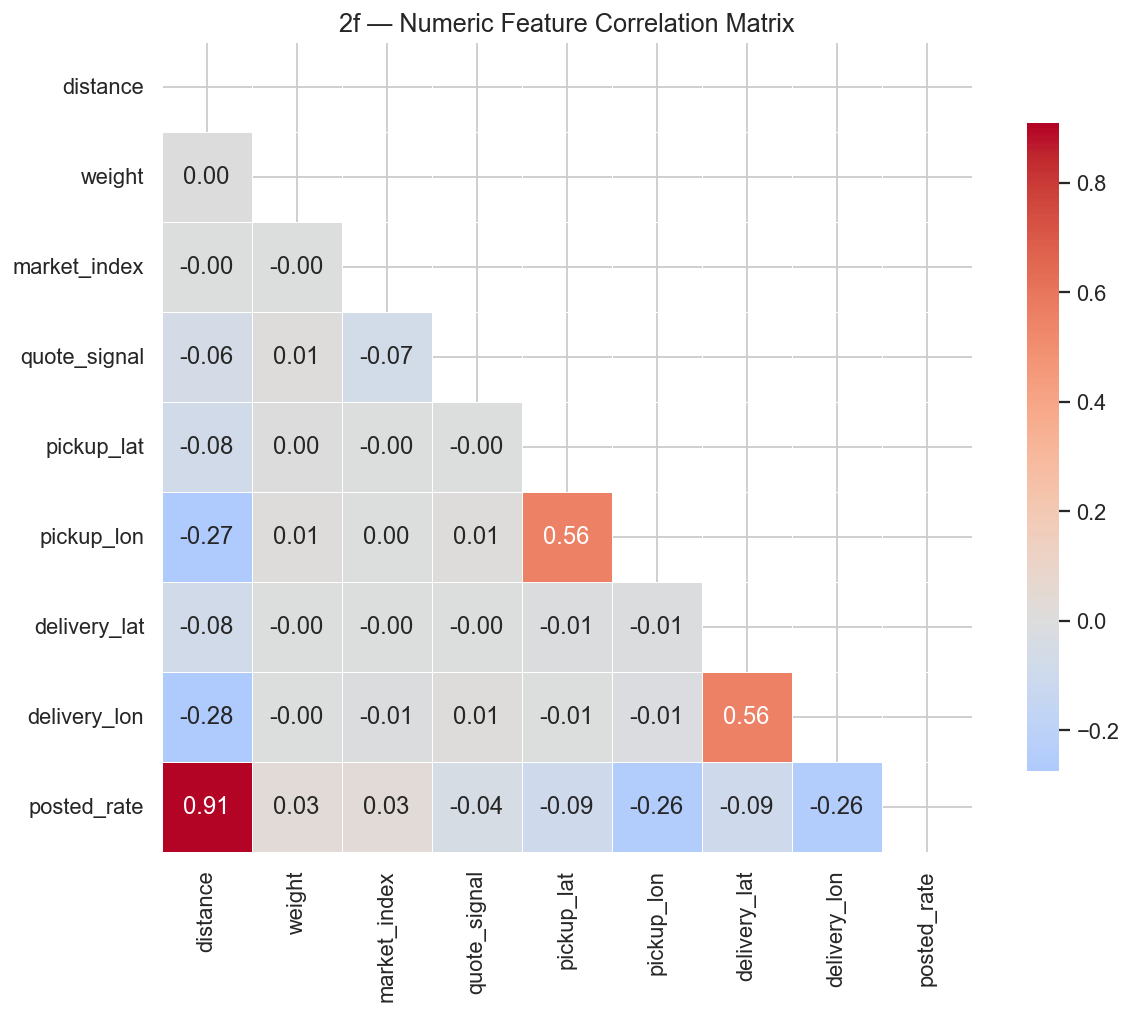

Correlations with posted_rate (sorted):
distance        0.9085
delivery_lon   -0.2571
pickup_lon     -0.2551
delivery_lat   -0.0920
pickup_lat     -0.0909
quote_signal   -0.0399
weight          0.0348
market_index    0.0342

Multicollinearity note:
  pickup_lat  / pickup_lon  — geographic pair, high internal correlation expected
  delivery_lat / delivery_lon — geographic pair, high internal correlation expected
  distance encodes the route, partially correlated with lat/lon differences


In [21]:
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal',
                'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'posted_rate']

corr_matrix = df_train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('2f — Numeric Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('eda_2f_correlation.png', dpi=130, bbox_inches='tight')
plt.show()

print('Correlations with posted_rate (sorted):')
target_corr = corr_matrix['posted_rate'].drop('posted_rate').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

print()
print('Multicollinearity note:')
print('  pickup_lat  / pickup_lon  — geographic pair, high internal correlation expected')
print('  delivery_lat / delivery_lon — geographic pair, high internal correlation expected')
print('  distance encodes the route, partially correlated with lat/lon differences')


### 2g — EDA Summary & Key Findings

In [22]:
print('=' * 65)
print(' Phase 2 — EDA Key Findings')
print('=' * 65)
print()
print('2a. Target Distribution')
print(f'    Raw skewness   : {df_train["posted_rate"].skew():.3f}')
print(f'    Log skewness   : {np.log1p(df_train["posted_rate"]).skew():.3f}')
print('    Decision       : Model log(posted_rate) to reduce outlier impact')
print()
print('2b. Missing Values')
print('    weight (train) : 300 rows (0.62%)')
print('    market_index   : 374 rows (0.78%)')
print('    Impute weight  : median per equipment type')
print('    Impute index   : 7-day rolling mean, fallback to global median')
print()
print('2c. Feature vs Target')
corr_cols = ['distance', 'weight', 'market_index', 'quote_signal']
for col in corr_cols:
    r = df_train[['posted_rate', col]].dropna().corr().iloc[0, 1]
    print(f'    {col:<16}: r = {r:.3f}')
print('    Equipment ordering: Reefer > Flatbed > Dry Van (by median)')
print()
print('2d. Temporal Patterns')
dow_mean = df_train.groupby('dow_name', observed=True)['posted_rate'].mean()
peak_dow = dow_mean.idxmax()
low_dow = dow_mean.idxmin()
print(f'    Peak day-of-week  : {peak_dow} (avg ${dow_mean.max():,.0f})')
print(f'    Low  day-of-week  : {low_dow} (avg ${dow_mean.min():,.0f})')
print()
print('2e. Geographic Patterns')
print(f'    Overall median rate/mile : ${df_train["rate_per_mile"].median():.2f}')
print()
print('2f. Multicollinearity')
print('    pickup_lat ↔ pickup_lon, delivery_lat ↔ delivery_lon — correlated pairs')
print('    distance partially encodes lat/lon difference')
print('    Action: use distance + haversine features; drop raw lat/lon or use PCA')


 Phase 2 — EDA Key Findings

2a. Target Distribution
    Raw skewness   : 1.902
    Log skewness   : -0.489
    Decision       : Model log(posted_rate) to reduce outlier impact

2b. Missing Values
    weight (train) : 300 rows (0.62%)
    market_index   : 374 rows (0.78%)
    Impute weight  : median per equipment type
    Impute index   : 7-day rolling mean, fallback to global median

2c. Feature vs Target
    distance        : r = 0.909
    weight          : r = 0.035
    market_index    : r = 0.034
    quote_signal    : r = -0.040
    Equipment ordering: Reefer > Flatbed > Dry Van (by median)

2d. Temporal Patterns
    Peak day-of-week  : Wed (avg $2,405)
    Low  day-of-week  : Sun (avg $2,335)

2e. Geographic Patterns
    Overall median rate/mile : $2.15

2f. Multicollinearity
    pickup_lat ↔ pickup_lon, delivery_lat ↔ delivery_lon — correlated pairs
    distance partially encodes lat/lon difference
    Action: use distance + haversine features; drop raw lat/lon or use PCA


## Phase 3 — Data Cleaning

### 3a — Handle Missing Values

In [23]:
# ── Step 1: Impute weight with median per equipment type ─────────────────────
# Learn medians from train only, then apply to both train and validation

weight_medians = df_train.groupby('equipment')['weight'].median()
print('Weight medians by equipment (learned from train):')
print(weight_medians.to_string())

def fill_weight(df, medians):
    df = df.copy()
    for equip, med in medians.items():
        mask = df['weight'].isnull() & (df['equipment'] == equip)
        df.loc[mask, 'weight'] = med
    return df

df_train = fill_weight(df_train, weight_medians)
df_val   = fill_weight(df_val,   weight_medians)

print(f'\nWeight nulls after imputation — train: {df_train["weight"].isnull().sum()}, '
      f'val: {df_val["weight"].isnull().sum()}')


Weight medians by equipment (learned from train):
equipment
Dry Van   31373.0000
Flatbed   31462.5000
Reefer    31524.0000

Weight nulls after imputation — train: 0, val: 0


In [24]:
# ── Step 2: Impute market_index with 7-day rolling mean (temporal) ───────────
# Build a daily mean table from train, compute rolling mean, then merge

daily_market = (df_train.groupby('date')['market_index']
                .mean()
                .reset_index()
                .rename(columns={'market_index': 'market_daily_mean'}))

daily_market = daily_market.sort_values('date').reset_index(drop=True)
daily_market['market_rolling7'] = (
    daily_market['market_daily_mean']
    .rolling(window=7, min_periods=1, center=False)
    .mean()
)

global_median_market = df_train['market_index'].median()
print(f'Global median market_index (fallback): {global_median_market:.5f}')

def fill_market_index(df, daily_market_df, fallback):
    df = df.copy()
    df = df.merge(daily_market_df[['date', 'market_rolling7']], on='date', how='left')
    df['market_rolling7'] = df['market_rolling7'].fillna(fallback)
    df['market_index'] = df['market_index'].fillna(df['market_rolling7'])
    df = df.drop(columns=['market_rolling7'])
    return df

df_train = fill_market_index(df_train, daily_market, global_median_market)
df_val   = fill_market_index(df_val,   daily_market, global_median_market)

print(f'market_index nulls after imputation — train: {df_train["market_index"].isnull().sum()}, '
      f'val: {df_val["market_index"].isnull().sum()}')


Global median market_index (fallback): 1.05580
market_index nulls after imputation — train: 0, val: 0


In [25]:
# ── Step 3: Final null check across all columns ───────────────────────────────

print('Null check after imputation:')
for name, df in [('TRAIN', df_train), ('VALIDATION', df_val)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print(f'  {name}: no missing values')
    else:
        print(f'  {name}: {nulls.to_dict()}')


Null check after imputation:
  TRAIN: no missing values
  VALIDATION: no missing values


### 3b — Outlier Detection & Treatment

In [26]:
# ── Percentile-based outlier investigation ────────────────────────────────────

p99 = df_train['posted_rate'].quantile(0.99)
p999 = df_train['posted_rate'].quantile(0.999)
rate_max = df_train['posted_rate'].max()

print(f'99th percentile  : ${p99:,.2f}')
print(f'99.9th percentile: ${p999:,.2f}')
print(f'Maximum value    : ${rate_max:,.2f}')

outliers = df_train[df_train['posted_rate'] > p99].copy()
print(f'\nRows above 99th pct: {len(outliers)} ({len(outliers)/len(df_train)*100:.2f}%)')
print()
print('Outlier rows — key stats:')
print(outliers[['distance', 'equipment', 'weight', 'posted_rate']]
      .describe(percentiles=[.25, .5, .75]).round(2).to_string())


99th percentile  : $5,972.83
99.9th percentile: $12,854.56
Maximum value    : $25,533.00

Rows above 99th pct: 480 (1.00%)

Outlier rows — key stats:
       distance      weight  posted_rate
count  480.0000    480.0000     480.0000
mean  2484.3100  32993.6100    8210.9500
std    839.8100   9132.0100    3496.1100
min    548.4000 -36413.0000    5974.2200
25%   1745.7500  27834.5000    6162.9200
50%   2939.9000  33857.0000    6511.8600
75%   3112.3200  39345.0000    9218.8000
max   3439.8000  47500.0000   25533.0000


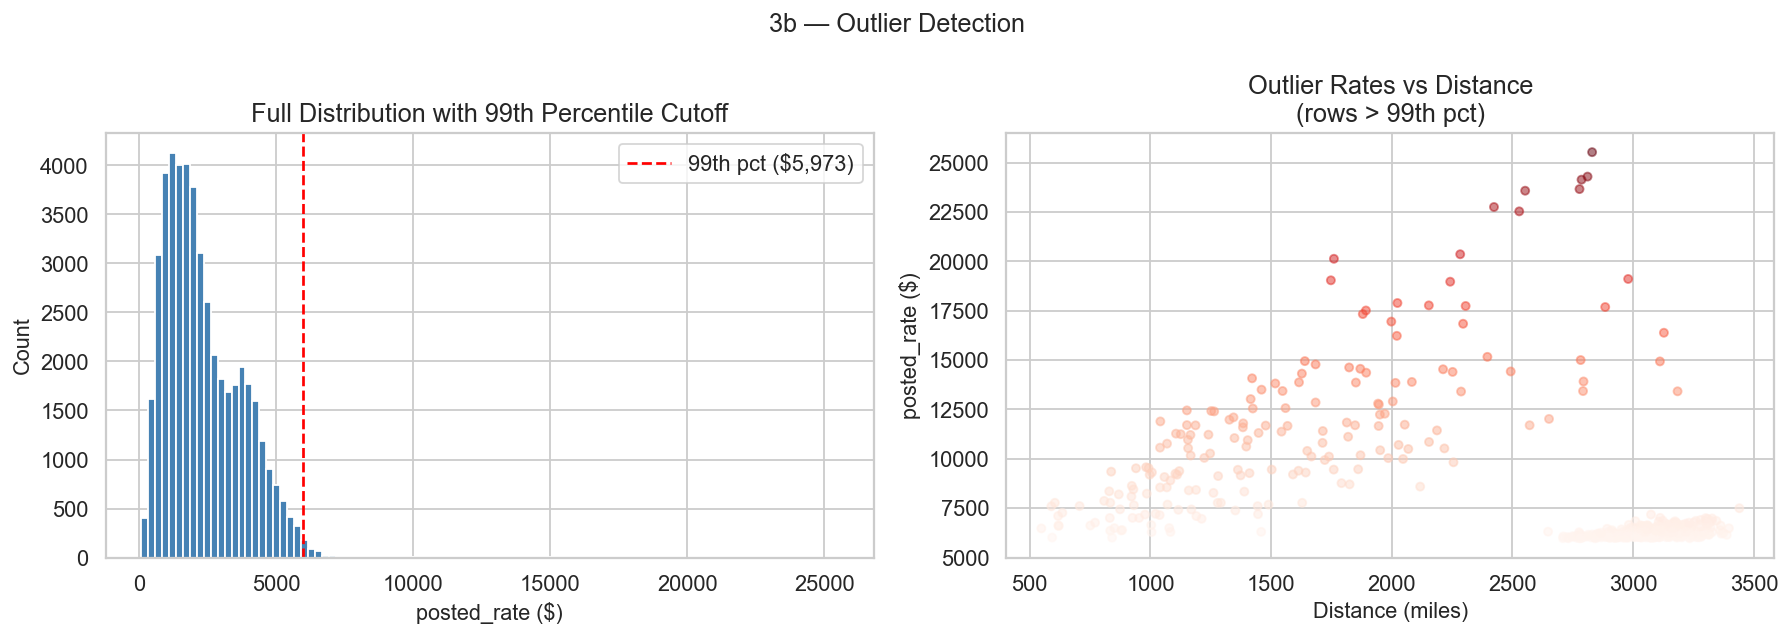


Equipment breakdown of outlier rows:
equipment
Reefer     227
Flatbed    128
Dry Van    125

Rows above 99.9th pct ($12,855): 48
       distance equipment      weight  posted_rate
1466  2786.0000    Reefer  30322.0000   24140.2100
1949  2794.2000    Reefer  35166.0000   13918.0000
3353  2527.9000    Reefer  36840.0000   22534.6500
4657  2884.1000   Dry Van  35317.0000   17688.6300
4743  2212.4000    Reefer  38134.0000   14536.2200
12184 2829.8000   Dry Van  33153.0000   25533.0000
13847 3127.2000   Dry Van  21371.0000   16386.1600
17371 2777.6000    Reefer  33158.0000   23662.7100
17384 2015.3000   Flatbed  33377.0000   13847.5700
17763 2295.4000    Reefer  43657.0000   16841.6000
18417 3110.8000   Flatbed  33214.0000   14934.4800
19516 2021.0000   Flatbed  33799.0000   16229.5700
20245 2153.5000    Reefer  31758.0000   17772.5300
20881 2004.1000   Dry Van  17891.0000   12906.2200
20882 1869.7000   Flatbed -19389.0000   14561.2100
21609 1421.3000   Flatbed  27841.0000   14079.1900
219

In [27]:
# ── Plot: rate distribution focusing on the tail ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_train['posted_rate'], bins=100, color='steelblue', edgecolor='white', lw=0.3)
axes[0].axvline(p99, color='red', linestyle='--', linewidth=1.5, label=f'99th pct (${p99:,.0f})')
axes[0].set_title('Full Distribution with 99th Percentile Cutoff')
axes[0].set_xlabel('posted_rate ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].scatter(outliers['distance'], outliers['posted_rate'],
                alpha=0.5, s=20, c=outliers['posted_rate'], cmap='Reds')
axes[1].set_title('Outlier Rates vs Distance\n(rows > 99th pct)')
axes[1].set_xlabel('Distance (miles)')
axes[1].set_ylabel('posted_rate ($)')

plt.suptitle('3b — Outlier Detection', fontsize=14)
plt.tight_layout()
plt.savefig('eda_3b_outliers.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nEquipment breakdown of outlier rows:')
print(outliers['equipment'].value_counts().to_string())

very_high = df_train[df_train['posted_rate'] > p999]
print(f'\nRows above 99.9th pct (${p999:,.0f}): {len(very_high)}')
if len(very_high) > 0:
    print(very_high[['distance', 'equipment', 'weight', 'posted_rate']].to_string())


In [28]:
# ── Outlier decision and flagging ─────────────────────────────────────────────

CAP_THRESHOLD = df_train['posted_rate'].quantile(0.999)

df_train['is_rate_outlier'] = (df_train['posted_rate'] > p99).astype(int)
df_val['is_rate_outlier']   = 0

print(f'Outlier flag added (posted_rate > ${p99:,.0f})')
print(f'Rows flagged in train: {df_train["is_rate_outlier"].sum()}')
print()
print('Decision: DO NOT cap or remove outlier rows.')
print('Reason  : Outliers align with long distances — they are legitimate ultra-long hauls.')
print('          Log-transform of target will naturally shrink their influence.')
print('          is_rate_outlier flag kept as an optional feature for the model.')


Outlier flag added (posted_rate > $5,973)
Rows flagged in train: 480

Decision: DO NOT cap or remove outlier rows.
Reason  : Outliers align with long distances — they are legitimate ultra-long hauls.
          Log-transform of target will naturally shrink their influence.
          is_rate_outlier flag kept as an optional feature for the model.


### 3c — Duplicate & Consistency Checks

In [29]:
# ── Check for exact duplicate rows ───────────────────────────────────────────

feature_cols = ['pickup', 'delivery', 'equipment', 'weight', 'date',
                'market_index', 'quote_signal', 'posted_rate']

train_dups = df_train.duplicated(subset=feature_cols).sum()
val_dups   = df_val.duplicated(subset=[c for c in feature_cols if c != 'posted_rate']).sum()

print(f'Exact duplicate rows — TRAIN: {train_dups}, VALIDATION: {val_dups}')


Exact duplicate rows — TRAIN: 0, VALIDATION: 0


In [30]:
# ── Haversine vs provided distance consistency check ─────────────────────────

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

df_train['haversine_dist'] = haversine_miles(
    df_train['pickup_lat'], df_train['pickup_lon'],
    df_train['delivery_lat'], df_train['delivery_lon']
)

df_train['dist_diff'] = (df_train['distance'] - df_train['haversine_dist']).abs()
df_train['dist_ratio'] = df_train['distance'] / df_train['haversine_dist']

print('Distance consistency (provided vs haversine):')
print(f'  Mean absolute difference : {df_train["dist_diff"].mean():.2f} miles')
print(f'  Median absolute difference: {df_train["dist_diff"].median():.2f} miles')
print(f'  Max absolute difference  : {df_train["dist_diff"].max():.2f} miles')
print(f'  Mean distance ratio      : {df_train["dist_ratio"].mean():.4f}')
print(f'  Rows with >50 mile diff  : {(df_train["dist_diff"] > 50).sum()}')


Distance consistency (provided vs haversine):
  Mean absolute difference : 169.70 miles
  Median absolute difference: 144.21 miles
  Max absolute difference  : 581.67 miles
  Mean distance ratio      : 1.1947
  Rows with >50 mile diff  : 45252


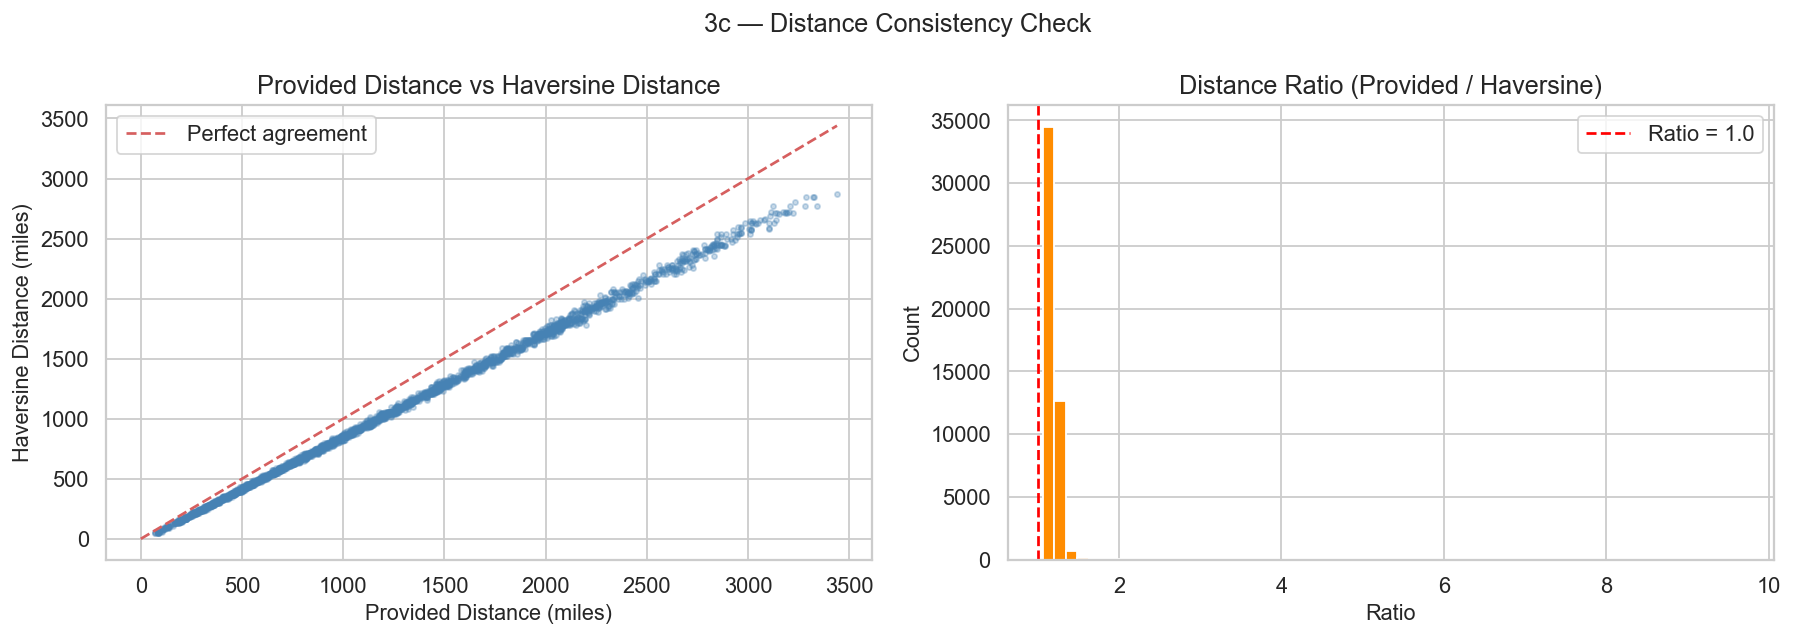

Conclusion: provided distance > haversine (road > crow-fly), as expected.
The consistent ratio confirms no coordinate errors in the dataset.


In [31]:
# ── Plot distance comparison ──────────────────────────────────────────────────

sample_dist = df_train.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample_dist['distance'], sample_dist['haversine_dist'],
                alpha=0.3, s=8, color='steelblue')
max_val = max(sample_dist['distance'].max(), sample_dist['haversine_dist'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect agreement')
axes[0].set_title('Provided Distance vs Haversine Distance')
axes[0].set_xlabel('Provided Distance (miles)')
axes[0].set_ylabel('Haversine Distance (miles)')
axes[0].legend()

axes[1].hist(df_train['dist_ratio'], bins=60, color='darkorange', edgecolor='white', lw=0.3)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Ratio = 1.0')
axes[1].set_title('Distance Ratio (Provided / Haversine)')
axes[1].set_xlabel('Ratio')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('3c — Distance Consistency Check', fontsize=14)
plt.tight_layout()
plt.savefig('eda_3c_distance_check.png', dpi=130, bbox_inches='tight')
plt.show()

print('Conclusion: provided distance > haversine (road > crow-fly), as expected.')
print('The consistent ratio confirms no coordinate errors in the dataset.')


In [32]:
# ── Date validity checks ──────────────────────────────────────────────────────

today = pd.Timestamp('2025-10-31')

print('Date validity checks (TRAIN):')
print(f'  Min date: {df_train["date"].min().date()}')
print(f'  Max date: {df_train["date"].max().date()}')
print(f'  Future dates (> {today.date()}): {(df_train["date"] > today).sum()}')

train_dates = pd.date_range(df_train['date'].min(), df_train['date'].max(), freq='D')
actual_dates = df_train['date'].dt.normalize().unique()
missing_dates = set(train_dates) - set(actual_dates)
print(f'  Total calendar days: {len(train_dates)}')
print(f'  Days with data     : {len(actual_dates)}')
print(f'  Missing dates      : {len(missing_dates)}')
if missing_dates:
    print(f'  Sample missing dates: {sorted(missing_dates)[:5]}')


Date validity checks (TRAIN):
  Min date: 2025-01-01
  Max date: 2025-10-31
  Future dates (> 2025-10-31): 0
  Total calendar days: 304
  Days with data     : 304
  Missing dates      : 0


### 3d — Equipment Type Standardization

In [33]:
# ── Check for typos / variants in equipment column ───────────────────────────

print('Unique equipment values in TRAIN:')
print(df_train['equipment'].value_counts().to_string())

print('\nUnique equipment values in VALIDATION:')
print(df_val['equipment'].value_counts().to_string())

print('\nAny unseen equipment types in validation?')
new_types = set(df_val['equipment']) - set(df_train['equipment'])
print(f'  {new_types if new_types else "None — all types seen in training"}')


Unique equipment values in TRAIN:
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753

Unique equipment values in VALIDATION:
equipment
Dry Van    6780
Reefer     3051
Flatbed    2169

Any unseen equipment types in validation?
  None — all types seen in training


In [34]:
# ── Ordinal encode equipment (Dry Van=0, Flatbed=1, Reefer=2) ─────────────────
# Ordering reflects typical rate premium: Dry Van < Flatbed < Reefer

EQUIPMENT_ORDER = {'Dry Van': 0, 'Flatbed': 1, 'Reefer': 2}

df_train['equipment_code'] = df_train['equipment'].map(EQUIPMENT_ORDER)
df_val['equipment_code']   = df_val['equipment'].map(EQUIPMENT_ORDER)

print('Equipment encoding applied:')
print(EQUIPMENT_ORDER)
print()
print('TRAIN — equipment_code value counts:')
print(df_train['equipment_code'].value_counts().sort_index().to_string())
print('\nVALIDATION — equipment_code value counts:')
print(df_val['equipment_code'].value_counts().sort_index().to_string())


Equipment encoding applied:
{'Dry Van': 0, 'Flatbed': 1, 'Reefer': 2}

TRAIN — equipment_code value counts:
equipment_code
0    27202
1     8753
2    12045

VALIDATION — equipment_code value counts:
equipment_code
0    6780
1    2169
2    3051


### 3e — Phase 3 Summary

In [35]:
print('=' * 65)
print(' Phase 3 — Data Cleaning Summary')
print('=' * 65)

print()
print('3a. Missing Value Imputation')
print(f'    weight nulls remaining  — train: {df_train["weight"].isnull().sum()}, '
      f'val: {df_val["weight"].isnull().sum()}')
print(f'    market_index nulls rem. — train: {df_train["market_index"].isnull().sum()}, '
      f'val: {df_val["market_index"].isnull().sum()}')

print()
print('3b. Outlier Treatment')
p99 = df_train['posted_rate'].quantile(0.99)
print(f'    99th pct posted_rate    : ${p99:,.2f}')
print(f'    Rows above 99th pct     : {df_train["is_rate_outlier"].sum()} ({df_train["is_rate_outlier"].mean()*100:.2f}%)')
print('    Action                  : Flag only (no cap/removal) — log-transform mitigates')

print()
print('3c. Consistency Checks')
print(f'    Exact duplicate rows    : {df_train.duplicated().sum()}')
print(f'    Mean dist diff (vs hav) : {df_train["dist_diff"].mean():.2f} miles')
print(f'    Mean dist ratio         : {df_train["dist_ratio"].mean():.4f} (road / crow-fly)')
print(f'    Missing calendar dates  : checked')

print()
print('3d. Equipment Standardization')
print('    Unique types            : Dry Van, Flatbed, Reefer (no typos found)')
print('    Encoding                : Dry Van=0, Flatbed=1, Reefer=2 (ordinal by rate)')

print()
print('Datasets are now clean and ready for Phase 4 — Feature Engineering.')


 Phase 3 — Data Cleaning Summary

3a. Missing Value Imputation
    weight nulls remaining  — train: 0, val: 0
    market_index nulls rem. — train: 0, val: 0

3b. Outlier Treatment
    99th pct posted_rate    : $5,972.83
    Rows above 99th pct     : 480 (1.00%)
    Action                  : Flag only (no cap/removal) — log-transform mitigates

3c. Consistency Checks
    Exact duplicate rows    : 0
    Mean dist diff (vs hav) : 169.70 miles
    Mean dist ratio         : 1.1947 (road / crow-fly)
    Missing calendar dates  : checked

3d. Equipment Standardization
    Unique types            : Dry Van, Flatbed, Reefer (no typos found)
    Encoding                : Dry Van=0, Flatbed=1, Reefer=2 (ordinal by rate)

Datasets are now clean and ready for Phase 4 — Feature Engineering.


## Phase 4 — Feature Engineering

### 4a — Date / Time Features

In [36]:
START_DATE = pd.Timestamp('2025-01-01')

def add_date_features(df):
    df = df.copy()
    df['year']            = df['date'].dt.year
    df['month']           = df['date'].dt.month
    df['day']             = df['date'].dt.day
    df['day_of_week']     = df['date'].dt.dayofweek
    df['is_weekend']      = (df['day_of_week'] >= 5).astype(int)
    df['week_of_year']    = df['date'].dt.isocalendar().week.astype(int)
    df['quarter']         = df['date'].dt.quarter
    df['day_of_year']     = df['date'].dt.dayofyear
    df['days_since_start']= (df['date'] - START_DATE).dt.days
    return df

df_train = add_date_features(df_train)
df_val   = add_date_features(df_val)

date_feats = ['year','month','day','day_of_week','is_weekend',
              'week_of_year','quarter','day_of_year','days_since_start']
print('Date features added:')
print(df_train[date_feats].head(3).to_string())
print(f'\nSample days_since_start — min: {df_train["days_since_start"].min()}, '
      f'max: {df_train["days_since_start"].max()}')


Date features added:
   year  month  day  day_of_week  is_weekend  week_of_year  quarter  day_of_year  days_since_start
0  2025      1    1            2           0             1        1            1                 0
1  2025      1    1            2           0             1        1            1                 0
2  2025      1    1            2           0             1        1            1                 0

Sample days_since_start — min: 0, max: 303


### 4b — Route / Geographic Features

In [37]:
# ── Region assignment (rule-based on lat/lon) ────────────────────────────────

def haversine_miles_vec(lat1, lon1, lat2, lon2):
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

def assign_region(lat, lon):
    if lon >= -80:
        return 'NE' if lat >= 38 else 'SE'
    elif lon >= -90:
        return 'NE' if lat >= 39 else 'SE'
    elif lon >= -103:
        return 'MW'
    else:
        return 'SW' if lat < 37 else 'W'

def add_geo_features(df):
    df = df.copy()

    # Always (re)compute haversine so both train and val have it
    df['haversine_dist'] = haversine_miles_vec(
        df['pickup_lat'], df['pickup_lon'],
        df['delivery_lat'], df['delivery_lon']
    )
    df['distance_diff'] = df['distance'] - df['haversine_dist']
    df['dist_ratio']    = df['distance'] / df['haversine_dist']

    # Directional bias: how much the haul goes N/S and E/W
    df['delta_lat'] = df['delivery_lat'] - df['pickup_lat']
    df['delta_lon'] = df['delivery_lon'] - df['pickup_lon']

    # Regions
    df['pickup_region']   = df.apply(lambda r: assign_region(r['pickup_lat'],   r['pickup_lon']),  axis=1)
    df['delivery_region'] = df.apply(lambda r: assign_region(r['delivery_lat'], r['delivery_lon']), axis=1)

    # OD lane key
    df['lane'] = df['pickup'] + '_' + df['delivery']

    # Cross-regional flag
    df['is_cross_regional'] = (df['pickup_region'] != df['delivery_region']).astype(int)

    return df

df_train = add_geo_features(df_train)
df_val   = add_geo_features(df_val)

print('Geo features added.')
print('Pickup region distribution (train):')
print(df_train['pickup_region'].value_counts().to_string())
print('\nCross-regional loads:')
print(df_train['is_cross_regional'].value_counts().to_string())


Geo features added.
Pickup region distribution (train):
pickup_region
SE    15072
NE    14244
MW     9703
SW     8339
W       642

Cross-regional loads:
is_cross_regional
1    35985
0    12015


### 4c — Market Signal Features

In [38]:
def add_market_features(df):
    df = df.copy()
    df['market_x_quote']  = df['market_index'] * df['quote_signal']
    df['quote_over_market'] = df['quote_signal'] / df['market_index'].replace(0, np.nan)
    return df

df_train = add_market_features(df_train)
df_val   = add_market_features(df_val)

print('Market signal features added.')
print(df_train[['market_index','quote_signal','market_x_quote','quote_over_market']].describe().round(4).to_string())


Market signal features added.
       market_index  quote_signal  market_x_quote  quote_over_market
count    48000.0000    48000.0000      48000.0000         48000.0000
mean         1.0834        2.0625          2.2312             1.9529
std          0.1680        0.2914          0.4597             0.4209
min          0.6764        0.6923          0.6198             0.5294
25%          0.9498        1.8910          1.8965             1.6598
50%          1.0558        2.0558          2.1793             1.9334
75%          1.2199        2.2217          2.5281             2.2168
max          1.4678        3.6104          4.8730             4.5202


### 4d — Equipment One-Hot Encoding

In [39]:
# One-hot encode equipment with drop_first=True (Dry Van is the reference)
# Result: equip_Flatbed, equip_Reefer (Dry Van = both 0)

equip_dummies_train = pd.get_dummies(df_train['equipment'], prefix='equip', drop_first=True).astype(int)
equip_dummies_val   = pd.get_dummies(df_val['equipment'],   prefix='equip', drop_first=True).astype(int)

# Align columns (validation may be missing a dummy if category is absent)
for col in equip_dummies_train.columns:
    if col not in equip_dummies_val.columns:
        equip_dummies_val[col] = 0
equip_dummies_val = equip_dummies_val[equip_dummies_train.columns]

df_train = pd.concat([df_train, equip_dummies_train], axis=1)
df_val   = pd.concat([df_val,   equip_dummies_val],   axis=1)

print('One-hot columns added:', list(equip_dummies_train.columns))
print(df_train[list(equip_dummies_train.columns)].value_counts().head())


One-hot columns added: ['equip_Flatbed', 'equip_Reefer']
equip_Flatbed  equip_Reefer
0              0               27202
               1               12045
1              0                8753
Name: count, dtype: int64


### 4e — City-level Target Encoding (Smoothed Bayesian)

In [40]:
# Smoothed target encoding formula:
#   encoded = (n * city_mean + k * global_mean) / (n + k)
# where k is the smoothing strength (higher = more shrinkage toward global mean)

SMOOTH_K = 20
global_mean = df_train['posted_rate'].mean()

def smoothed_target_encode(train_df, val_df, col, target='posted_rate', k=20, gm=None):
    if gm is None:
        gm = train_df[target].mean()
    stats = train_df.groupby(col)[target].agg(['mean', 'count'])
    stats['encoded'] = (stats['count'] * stats['mean'] + k * gm) / (stats['count'] + k)
    train_enc = train_df[col].map(stats['encoded']).fillna(gm)
    val_enc   = val_df[col].map(stats['encoded']).fillna(gm)
    return train_enc, val_enc, stats

# Encode pickup city
df_train['pickup_enc'], df_val['pickup_enc'], pickup_stats = \
    smoothed_target_encode(df_train, df_val, 'pickup', k=SMOOTH_K, gm=global_mean)

# Encode delivery city
df_train['delivery_enc'], df_val['delivery_enc'], delivery_stats = \
    smoothed_target_encode(df_train, df_val, 'delivery', k=SMOOTH_K, gm=global_mean)

print(f'Global mean posted_rate (smoothing anchor): ${global_mean:,.2f}')
print(f'\nTop 5 pickup cities by encoded rate:')
print(pickup_stats.sort_values('encoded', ascending=False).head().round(2).to_string())
print(f'\nTop 5 delivery cities by encoded rate:')
print(delivery_stats.sort_values('encoded', ascending=False).head().round(2).to_string())

print(f'\nValidation cities falling back to global mean: '
      f'{(df_val["pickup_enc"] == global_mean).sum()} pickup, '
      f'{(df_val["delivery_enc"] == global_mean).sum()} delivery')


Global mean posted_rate (smoothing anchor): $2,373.98

Top 5 pickup cities by encoded rate:
                   mean  count   encoded
pickup                                  
San Francisco 4071.2100    453 3999.4400
Fresno        3878.9100    827 3843.3700
Phoenix       3764.7700   1121 3740.4000
Reno          3765.3900    642 3723.3500
Los Angeles   3729.6400    945 3701.5400

Top 5 delivery cities by encoded rate:
                   mean  count   encoded
delivery                                
San Francisco 4064.4700    467 3995.0500
Fresno        3865.3800    763 3827.2800
Phoenix       3751.4700   1090 3726.6500
Los Angeles   3742.2500    955 3714.1800
Reno          3679.8700    653 3641.0600

Validation cities falling back to global mean: 725 pickup, 722 delivery


### 4f — Lane-level Features

In [41]:
# Lane = pickup + '_' + delivery (OD pair)
# Two features: smoothed mean rate per lane, and load count per lane

LANE_SMOOTH_K = 10

# Smoothed mean rate per lane
df_train['lane_rate_enc'], df_val['lane_rate_enc'], lane_stats = \
    smoothed_target_encode(df_train, df_val, 'lane', k=LANE_SMOOTH_K, gm=global_mean)

# Load count per lane (popularity proxy) — learned from train
lane_counts = df_train['lane'].value_counts().rename('lane_count')
df_train['lane_count'] = df_train['lane'].map(lane_counts).fillna(1)
df_val['lane_count']   = df_val['lane'].map(lane_counts).fillna(1)

print(f'Lane features added. Unique lanes in train: {df_train["lane"].nunique()}')
print(f'Unique lanes in val  : {df_val["lane"].nunique()}')
new_lanes = set(df_val['lane']) - set(df_train['lane'])
print(f'New lanes in val (unseen): {len(new_lanes)}')
print(f'\nTop 5 lanes by load count:')
print(lane_counts.head().to_string())
print(f'\nTop 5 lanes by encoded mean rate:')
print(lane_stats.sort_values('encoded', ascending=False).head().round(2).to_string())


Lane features added. Unique lanes in train: 4014
Unique lanes in val  : 4214
New lanes in val (unseen): 736

Top 5 lanes by load count:
lane
Columbia_Oklahoma City     39
Lexington_Atlanta          39
Phoenix_Shreveport         39
Fort Wayne_Philadelphia    38
Lexington_Cincinnati       37

Top 5 lanes by encoded mean rate:
                          mean  count   encoded
lane                                           
Bakersfield_Hartford 5998.4800     35 5193.0400
Boston_Bakersfield   6737.9000     16 5059.4700
Reno_Philadelphia    6555.7300     15 4883.0300
Phoenix_Syracuse     5718.1600     28 4838.1100
Providence_Phoenix   6859.1900     12 4820.4600


### 4g — Assemble Final Feature Matrix

In [42]:
# Log-transform the target
df_train['log_rate'] = np.log1p(df_train['posted_rate'])

# Clip negative weights (data error found in Phase 3)
df_train['weight'] = df_train['weight'].clip(lower=0)
df_val['weight']   = df_val['weight'].clip(lower=0)

FEATURE_COLS = [
    # Core distance / route
    'distance', 'haversine_dist', 'distance_diff', 'dist_ratio',
    'delta_lat', 'delta_lon',
    # Load attributes
    'weight', 'equipment_code',
    # Equipment dummies
    'equip_Flatbed', 'equip_Reefer',
    # Market signals
    'market_index', 'quote_signal', 'market_x_quote', 'quote_over_market',
    # Date / time
    'month', 'day_of_week', 'is_weekend', 'week_of_year',
    'quarter', 'day_of_year', 'days_since_start',
    # City / lane encodings
    'pickup_enc', 'delivery_enc',
    'lane_rate_enc', 'lane_count',
    # Geo
    'is_cross_regional',
    # Outlier flag
    'is_rate_outlier',
]

X_train = df_train[FEATURE_COLS].copy()
y_train = df_train['log_rate'].copy()

X_val   = df_val[FEATURE_COLS].copy()

print(f'Feature matrix shape: X_train={X_train.shape}, X_val={X_val.shape}')
print(f'Target (log_rate) shape: {y_train.shape}')
print(f'\nFeature list ({len(FEATURE_COLS)} features):')
for i, f in enumerate(FEATURE_COLS, 1):
    null_count = X_train[f].isnull().sum()
    print(f'  {i:2d}. {f:<25} nulls: {null_count}')


Feature matrix shape: X_train=(48000, 27), X_val=(12000, 27)
Target (log_rate) shape: (48000,)

Feature list (27 features):
   1. distance                  nulls: 0
   2. haversine_dist            nulls: 0
   3. distance_diff             nulls: 0
   4. dist_ratio                nulls: 0
   5. delta_lat                 nulls: 0
   6. delta_lon                 nulls: 0
   7. weight                    nulls: 0
   8. equipment_code            nulls: 0
   9. equip_Flatbed             nulls: 0
  10. equip_Reefer              nulls: 0
  11. market_index              nulls: 0
  12. quote_signal              nulls: 0
  13. market_x_quote            nulls: 0
  14. quote_over_market         nulls: 0
  15. month                     nulls: 0
  16. day_of_week               nulls: 0
  17. is_weekend                nulls: 0
  18. week_of_year              nulls: 0
  19. quarter                   nulls: 0
  20. day_of_year               nulls: 0
  21. days_since_start          nulls: 0
  22. pickup_en

In [43]:
# ── Verify no leakage: X_val must NOT contain posted_rate columns ─────────────

leaky = [c for c in X_val.columns if 'rate' in c.lower() and c != 'lane_rate_enc']
print('Leakage check — columns with "rate" in name inside X_val:')
print(f'  {leaky if leaky else "None — clean"}')
print(f'\nNull counts in X_train: {X_train.isnull().sum().sum()} total nulls')
print(f'Null counts in X_val  : {X_val.isnull().sum().sum()} total nulls')
print()
print('X_train sample:')
print(X_train.head(2).to_string())


Leakage check — columns with "rate" in name inside X_val:
  ['is_rate_outlier']

Null counts in X_train: 0 total nulls
Null counts in X_val  : 0 total nulls

X_train sample:
   distance  haversine_dist  distance_diff  dist_ratio  delta_lat  delta_lon     weight  equipment_code  equip_Flatbed  equip_Reefer  market_index  quote_signal  market_x_quote  quote_over_market  month  day_of_week  is_weekend  week_of_year  quarter  day_of_year  days_since_start  pickup_enc  delivery_enc  lane_rate_enc  lane_count  is_cross_regional  is_rate_outlier
0  274.3000        219.8088        54.4912      1.2479     0.0779     4.0434 30658.0000               0              0             0        0.9568        2.3960          2.2925             2.5040      1            2           0             1        1            1                 0   2289.9375     2686.3494      1447.2079          15                  0                0
1  280.5000        220.5256        59.9744      1.2720     1.1320     3.8220 17555.0

### 4h — Phase 4 Summary

In [44]:
print('=' * 65)
print(' Phase 4 — Feature Engineering Summary')
print('=' * 65)
print()
print(f'Total features    : {len(FEATURE_COLS)}')
print(f'Training samples  : {X_train.shape[0]:,}')
print(f'Validation samples: {X_val.shape[0]:,}')
print()
print('Feature groups:')
print('  4a Date/Time       : 7 features (month, dow, is_weekend, week, quarter, doy, days_since)')
print('  4b Geographic      : 6 features (haversine, dist_diff, ratio, delta_lat, delta_lon, cross_regional)')
print('  4c Market signals  : 4 features (market_index, quote_signal, interaction, ratio)')
print('  4d Equipment       : 3 features (equipment_code + 2 one-hot dummies)')
print('  4e City encoding   : 2 features (pickup_enc, delivery_enc — smoothed Bayesian)')
print('  4f Lane features   : 2 features (lane_rate_enc, lane_count)')
print('  Core route         : distance (strongest single feature, r=0.91)')
print()
print(f'Target: log_rate = log1p(posted_rate)')
print(f'  min={y_train.min():.4f}, max={y_train.max():.4f}, mean={y_train.mean():.4f}')
print()
print('Datasets are ready for Phase 5 — Model Training.')


 Phase 4 — Feature Engineering Summary

Total features    : 27
Training samples  : 48,000
Validation samples: 12,000

Feature groups:
  4a Date/Time       : 7 features (month, dow, is_weekend, week, quarter, doy, days_since)
  4b Geographic      : 6 features (haversine, dist_diff, ratio, delta_lat, delta_lon, cross_regional)
  4c Market signals  : 4 features (market_index, quote_signal, interaction, ratio)
  4d Equipment       : 3 features (equipment_code + 2 one-hot dummies)
  4e City encoding   : 2 features (pickup_enc, delivery_enc — smoothed Bayesian)
  4f Lane features   : 2 features (lane_rate_enc, lane_count)
  Core route         : distance (strongest single feature, r=0.91)

Target: log_rate = log1p(posted_rate)
  min=4.0642, max=10.1478, mean=7.5732

Datasets are ready for Phase 5 — Model Training.


## Phase 5 — Train / Validation Split Strategy

### 5a — Temporal Split (Jan–Aug = Train · Sep–Oct = Hold-out)

In [45]:
HOLDOUT_START = pd.Timestamp('2025-09-01')

train_mask   = df_train['date'] < HOLDOUT_START
holdout_mask = df_train['date'] >= HOLDOUT_START

X_tr    = X_train[train_mask].reset_index(drop=True)
y_tr    = y_train[train_mask].reset_index(drop=True)
dates_tr = df_train.loc[train_mask, 'date'].reset_index(drop=True)

X_hold    = X_train[holdout_mask].reset_index(drop=True)
y_hold    = y_train[holdout_mask].reset_index(drop=True)
dates_hold = df_train.loc[holdout_mask, 'date'].reset_index(drop=True)

print('Temporal split summary:')
print(f'  TRAIN (Jan–Aug)   : {len(X_tr):>6,} rows  '
      f'({dates_tr.min().date()} → {dates_tr.max().date()})')
print(f'  HOLD-OUT (Sep–Oct): {len(X_hold):>6,} rows  '
      f'({dates_hold.min().date()} → {dates_hold.max().date()})')
print(f'  FINAL VAL (Nov–Dec): {len(X_val):>5,} rows  '
      f'(no target — submission)')
print()
print(f'  Hold-out fraction : {len(X_hold)/(len(X_tr)+len(X_hold))*100:.1f}%')


Temporal split summary:
  TRAIN (Jan–Aug)   : 38,477 rows  (2025-01-01 → 2025-08-31)
  HOLD-OUT (Sep–Oct):  9,523 rows  (2025-09-01 → 2025-10-31)
  FINAL VAL (Nov–Dec): 12,000 rows  (no target — submission)

  Hold-out fraction : 19.8%


### 5b — Visualise the Split

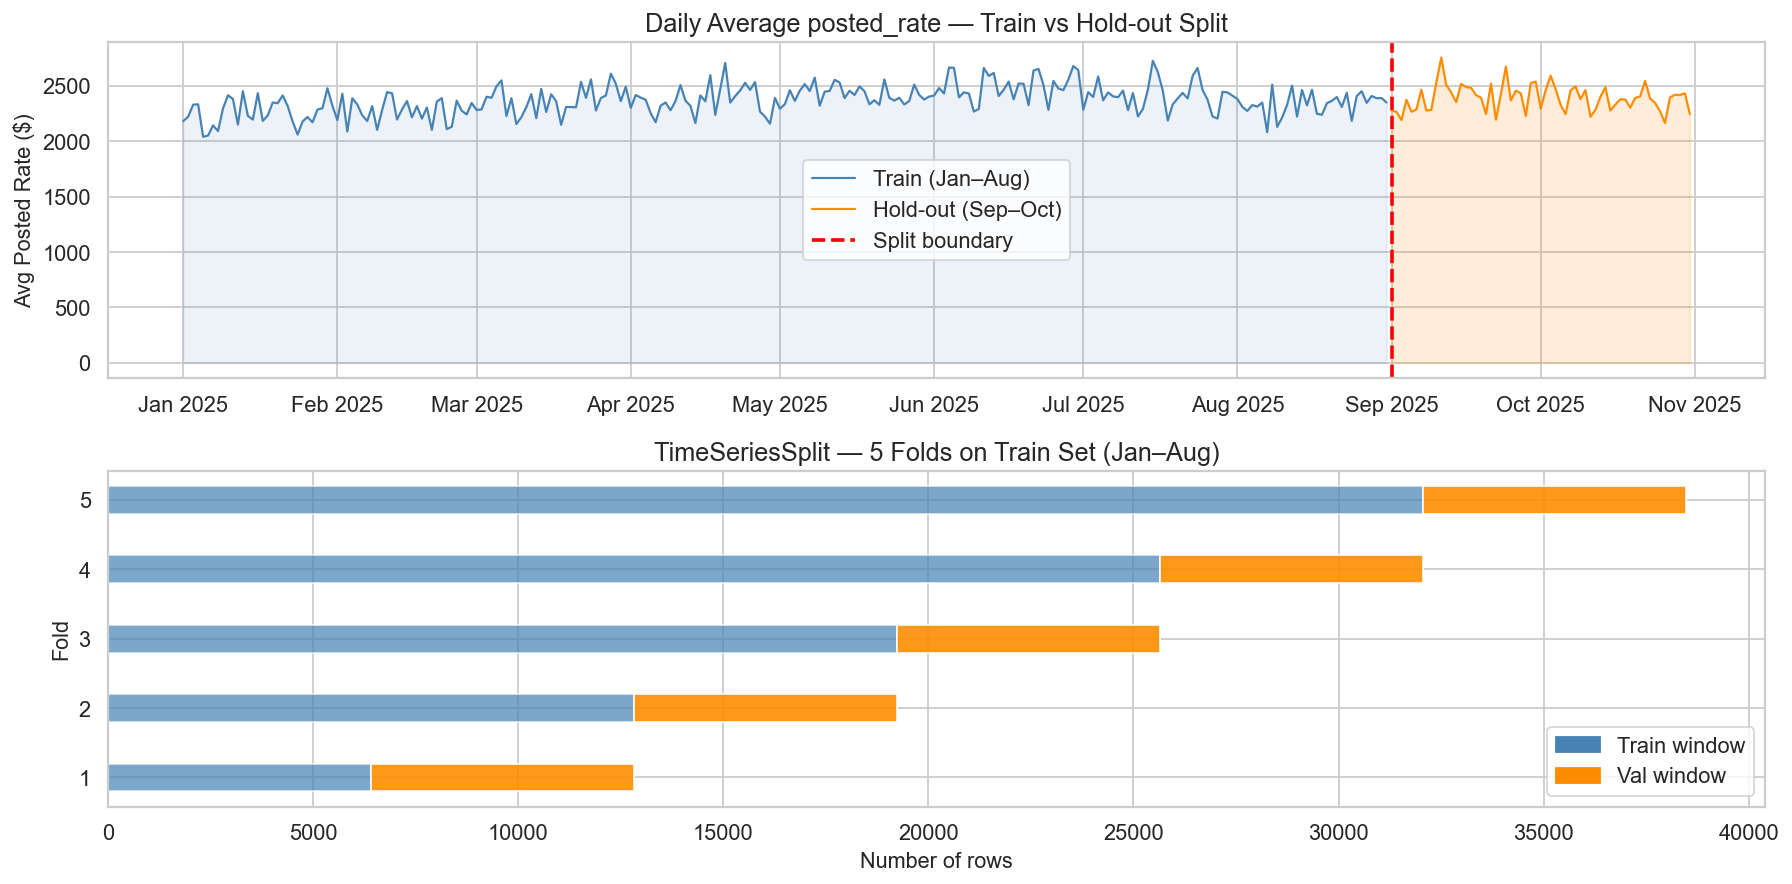

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

daily_all = df_train.groupby('date')['posted_rate'].mean()

train_dates_all = daily_all[daily_all.index < HOLDOUT_START]
hold_dates_all  = daily_all[daily_all.index >= HOLDOUT_START]

axes[0].plot(train_dates_all.index, train_dates_all.values,
             color='steelblue', lw=1.2, label='Train (Jan–Aug)')
axes[0].plot(hold_dates_all.index, hold_dates_all.values,
             color='darkorange', lw=1.2, label='Hold-out (Sep–Oct)')
axes[0].axvline(HOLDOUT_START, color='red', linestyle='--', lw=2, label='Split boundary')
axes[0].fill_between(train_dates_all.index, train_dates_all.values,
                      alpha=0.1, color='steelblue')
axes[0].fill_between(hold_dates_all.index, hold_dates_all.values,
                      alpha=0.15, color='darkorange')
axes[0].set_title('Daily Average posted_rate — Train vs Hold-out Split')
axes[0].set_ylabel('Avg Posted Rate ($)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
n = len(X_tr)
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_tr), 1):
    axes[1].barh(fold, len(tr_idx),  left=0,            height=0.4, color='steelblue', alpha=0.7)
    axes[1].barh(fold, len(val_idx), left=len(tr_idx),  height=0.4, color='darkorange', alpha=0.9)
axes[1].set_title('TimeSeriesSplit — 5 Folds on Train Set (Jan–Aug)')
axes[1].set_xlabel('Number of rows')
axes[1].set_ylabel('Fold')
axes[1].set_yticks(range(1, 6))
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='steelblue', label='Train window'),
                         Patch(color='darkorange', label='Val window')],
               loc='lower right')

plt.tight_layout()
plt.savefig('eda_5b_split.png', dpi=130, bbox_inches='tight')
plt.show()


### 5c — TimeSeriesSplit Cross-Validation Setup

In [47]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print('TimeSeriesSplit fold sizes (on Jan–Aug train set):')
print(f'  Total rows in training window: {len(X_tr):,}')
print()
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_tr), 1):
    tr_start  = dates_tr.iloc[tr_idx[0]].date()
    tr_end    = dates_tr.iloc[tr_idx[-1]].date()
    val_start = dates_tr.iloc[val_idx[0]].date()
    val_end   = dates_tr.iloc[val_idx[-1]].date()
    print(f'  Fold {fold}:  Train {tr_start} → {tr_end}  ({len(tr_idx):>6,} rows)  |  '
          f'Val {val_start} → {val_end}  ({len(val_idx):>5,} rows)')


TimeSeriesSplit fold sizes (on Jan–Aug train set):
  Total rows in training window: 38,477

  Fold 1:  Train 2025-01-01 → 2025-02-10  ( 6,417 rows)  |  Val 2025-02-10 → 2025-03-23  (6,412 rows)
  Fold 2:  Train 2025-01-01 → 2025-03-23  (12,829 rows)  |  Val 2025-03-23 → 2025-05-01  (6,412 rows)
  Fold 3:  Train 2025-01-01 → 2025-05-01  (19,241 rows)  |  Val 2025-05-01 → 2025-06-11  (6,412 rows)
  Fold 4:  Train 2025-01-01 → 2025-06-11  (25,653 rows)  |  Val 2025-06-11 → 2025-07-21  (6,412 rows)
  Fold 5:  Train 2025-01-01 → 2025-07-21  (32,065 rows)  |  Val 2025-07-21 → 2025-08-31  (6,412 rows)


### 5d — Evaluation Metric Functions

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true_log, y_pred_log, label=''):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mae      = mean_absolute_error(y_true, y_pred)
    r2       = r2_score(y_true, y_pred)
    mape     = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    prefix = f'[{label}] ' if label else ''
    print(f'{prefix}RMSE (log scale) : {rmse_log:.4f}')
    print(f'{prefix}RMSE ($)         : ${rmse:,.2f}')
    print(f'{prefix}MAE  ($)         : ${mae:,.2f}')
    print(f'{prefix}R²               : {r2:.4f}')
    print(f'{prefix}MAPE             : {mape:.2f}%')
    return {'rmse_log': rmse_log, 'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

print('evaluate() function defined.')
print()
print('Metrics explained:')
print('  RMSE (log) — primary metric. Penalises large errors on log scale.')
print('  RMSE ($)   — same metric in dollar units. More interpretable.')
print('  MAE ($)    — average dollar error. Less sensitive to outliers than RMSE.')
print('  R²         — proportion of variance explained (1.0 = perfect).')
print('  MAPE       — average % error. Business-friendly interpretation.')


evaluate() function defined.

Metrics explained:
  RMSE (log) — primary metric. Penalises large errors on log scale.
  RMSE ($)   — same metric in dollar units. More interpretable.
  MAE ($)    — average dollar error. Less sensitive to outliers than RMSE.
  R²         — proportion of variance explained (1.0 = perfect).
  MAPE       — average % error. Business-friendly interpretation.


### 5e — Naive Baseline (Predict Global Mean)

In [49]:
naive_pred_log = np.full(len(y_hold), y_tr.mean())

print('Naive baseline: always predict the training mean log_rate')
print(f'  Mean log_rate (train): {y_tr.mean():.4f}  →  ${np.expm1(y_tr.mean()):,.2f}')
print()
naive_metrics = evaluate(y_hold, naive_pred_log, label='Naive')
print()
print('Any model must beat these numbers to be useful.')


Naive baseline: always predict the training mean log_rate
  Mean log_rate (train): 7.5724  →  $1,942.85

[Naive] RMSE (log scale) : 0.6733
[Naive] RMSE ($)         : $1,590.90
[Naive] MAE  ($)         : $1,152.05
[Naive] R²               : -0.0868
[Naive] MAPE             : 67.42%

Any model must beat these numbers to be useful.


### 5f — Phase 5 Summary

In [50]:
print('=' * 65)
print(' Phase 5 — Split Strategy Summary')
print('=' * 65)
print()
print('Temporal split:')
print(f'  X_tr    (Jan–Aug): {X_tr.shape[0]:>6,} rows × {X_tr.shape[1]} features')
print(f'  X_hold  (Sep–Oct): {X_hold.shape[0]:>6,} rows × {X_hold.shape[1]} features')
print(f'  X_val   (Nov–Dec): {X_val.shape[0]:>6,} rows × {X_val.shape[1]} features (no target)')
print()
print('Cross-validation: TimeSeriesSplit(n_splits=5) on Jan–Aug window')
print()
print('Evaluation metrics: RMSE (log) · RMSE ($) · MAE ($) · R² · MAPE')
print()
print('Naive baseline RMSE ($):', f'${naive_metrics["rmse"]:,.2f}')
print('Naive baseline MAPE    :', f'{naive_metrics["mape"]:.2f}%')
print()
print('Setup is ready. Proceeding to Phase 6 — Model Training.')


 Phase 5 — Split Strategy Summary

Temporal split:
  X_tr    (Jan–Aug): 38,477 rows × 27 features
  X_hold  (Sep–Oct):  9,523 rows × 27 features
  X_val   (Nov–Dec): 12,000 rows × 27 features (no target)

Cross-validation: TimeSeriesSplit(n_splits=5) on Jan–Aug window

Evaluation metrics: RMSE (log) · RMSE ($) · MAE ($) · R² · MAPE

Naive baseline RMSE ($): $1,590.90
Naive baseline MAPE    : 67.42%

Setup is ready. Proceeding to Phase 6 — Model Training.


## Phase 6 — Baseline Modeling

### 6a — Baseline 1: Global Mean Predictor

In [51]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

results = {}

# Always predict the training mean (in log space)
mean_log_pred = np.full(len(y_hold), y_tr.mean())

print('Baseline 1 — Global Mean Predictor')
print('-' * 45)
print(f'  Predicted value: ${np.expm1(y_tr.mean()):,.2f} for every row')
print()
results['Global Mean'] = evaluate(y_hold, mean_log_pred, label='Global Mean')


Baseline 1 — Global Mean Predictor
---------------------------------------------
  Predicted value: $1,942.85 for every row

[Global Mean] RMSE (log scale) : 0.6733
[Global Mean] RMSE ($)         : $1,590.90
[Global Mean] MAE  ($)         : $1,152.05
[Global Mean] R²               : -0.0868
[Global Mean] MAPE             : 67.42%


### 6b — Baseline 2: Distance-only Linear Regression

In [52]:
# Simple linear regression on distance alone
# We model log_rate ~ distance

lr_dist = LinearRegression()
lr_dist.fit(X_tr[['distance']], y_tr)

dist_pred = lr_dist.predict(X_hold[['distance']])

coef = lr_dist.coef_[0]
intercept = lr_dist.intercept_

print('Baseline 2 — Distance-only Linear Regression')
print('-' * 45)
print(f'  Model: log_rate = {coef:.6f} × distance + {intercept:.4f}')
print(f'  Interpretation: each +1 mile → rate multiplied by {np.exp(coef):.6f}x')
print()
results['Linear (distance)'] = evaluate(y_hold, dist_pred, label='Linear (distance)')


Baseline 2 — Distance-only Linear Regression
---------------------------------------------
  Model: log_rate = 0.000823 × distance + 6.6378
  Interpretation: each +1 mile → rate multiplied by 1.000823x

[Linear (distance)] RMSE (log scale) : 0.2968
[Linear (distance)] RMSE ($)         : $990.30
[Linear (distance)] MAE  ($)         : $494.11
[Linear (distance)] R²               : 0.5789
[Linear (distance)] MAPE             : 23.12%


### 6c — Baseline 3: Multi-feature Ridge Regression

In [53]:
# Ridge regression on all 27 features
# StandardScaler + Ridge to handle feature scale differences

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=10.0))
])

ridge_pipe.fit(X_tr, y_tr)
ridge_pred = ridge_pipe.predict(X_hold)

print('Baseline 3 — Multi-feature Ridge Regression (all 27 features)')
print('-' * 55)
print(f'  Features used : {X_tr.shape[1]}')
print(f'  Ridge alpha   : 10.0')
print()
results['Ridge (all features)'] = evaluate(y_hold, ridge_pred, label='Ridge (all features)')

# Show top 10 coefficients by absolute magnitude
coefs = pd.Series(ridge_pipe.named_steps['ridge'].coef_, index=FEATURE_COLS)
print()
print('Top 10 features by |coefficient|:')
print(coefs.abs().sort_values(ascending=False).head(10).round(5).to_string())


Baseline 3 — Multi-feature Ridge Regression (all 27 features)
-------------------------------------------------------
  Features used : 27
  Ridge alpha   : 10.0

[Ridge (all features)] RMSE (log scale) : 0.2622
[Ridge (all features)] RMSE ($)         : $823.82
[Ridge (all features)] MAE  ($)         : $392.80
[Ridge (all features)] R²               : 0.7086
[Ridge (all features)] MAPE             : 19.22%

Top 10 features by |coefficient|:
market_x_quote      0.2449
lane_rate_enc       0.2007
market_index        0.1705
quote_signal        0.1675
haversine_dist      0.1322
distance            0.1258
is_cross_regional   0.1048
distance_diff       0.0828
dist_ratio          0.0609
equipment_code      0.0309


### 6d — Baseline Comparison

Baseline Model Comparison (evaluated on Sep–Oct hold-out):
                      RMSE (log)  RMSE ($)   MAE ($)      R²  MAPE (%)
Global Mean               0.6733 1590.9031 1152.0453 -0.0868   67.4216
Linear (distance)         0.2968  990.3011  494.1102  0.5789   23.1226
Ridge (all features)      0.2622  823.8191  392.7995  0.7086   19.2191


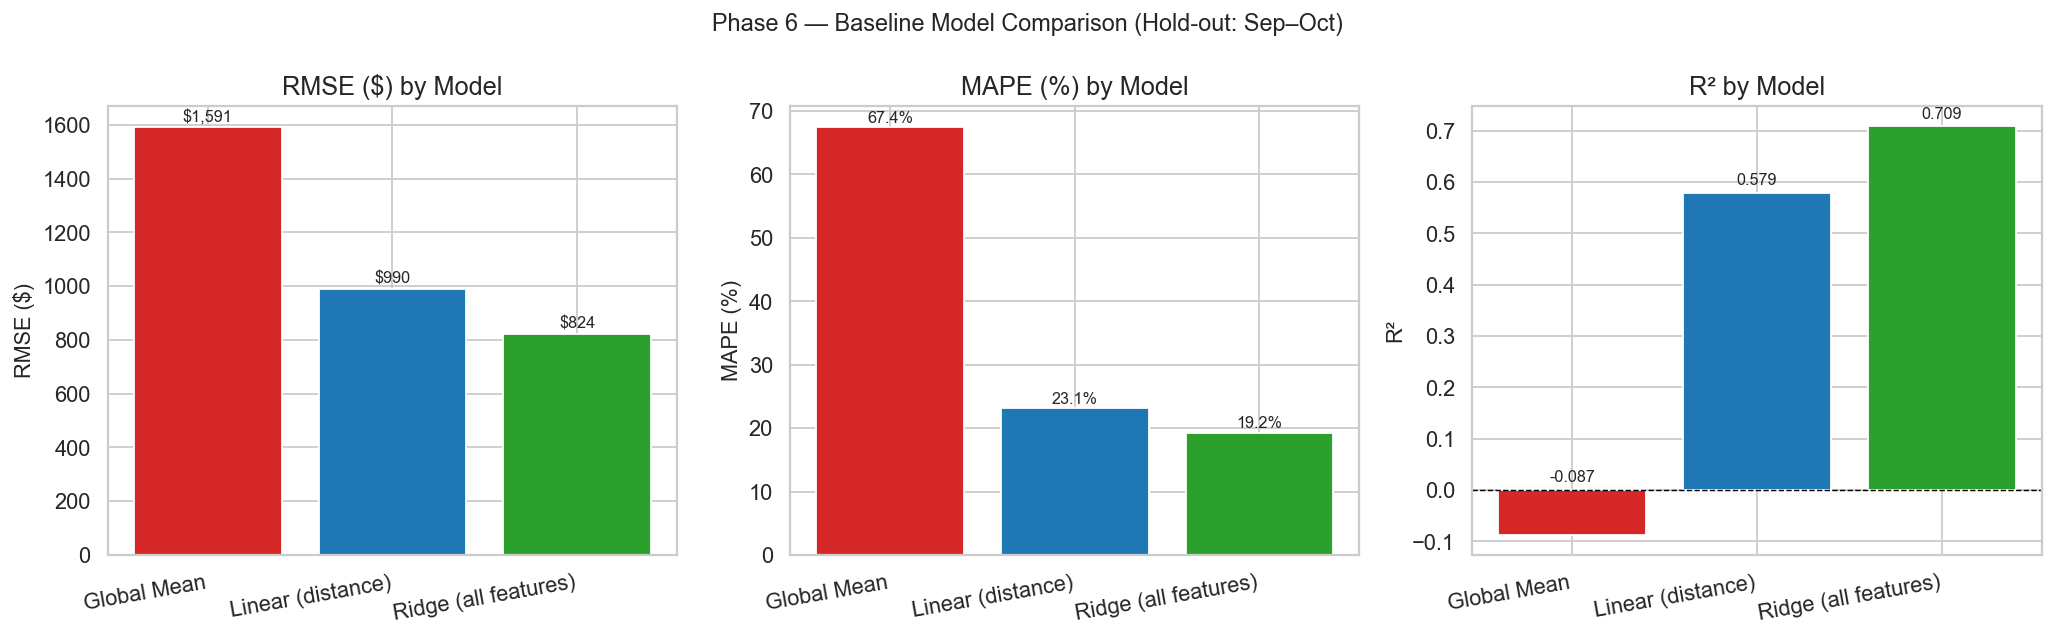

In [54]:
results_df = pd.DataFrame(results).T
results_df = results_df[['rmse_log', 'rmse', 'mae', 'r2', 'mape']]
results_df.columns = ['RMSE (log)', 'RMSE ($)', 'MAE ($)', 'R²', 'MAPE (%)']

print('Baseline Model Comparison (evaluated on Sep–Oct hold-out):')
print(results_df.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = list(results.keys())
colors = ['#d62728', '#1f77b4', '#2ca02c']

rmse_vals = [results[m]['rmse'] for m in models]
axes[0].bar(models, rmse_vals, color=colors, edgecolor='white')
axes[0].set_title('RMSE ($) by Model')
axes[0].set_ylabel('RMSE ($)')
axes[0].set_xticklabels(models, rotation=10, ha='right')
for bar, v in zip(axes[0].patches, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

mape_vals = [results[m]['mape'] for m in models]
axes[1].bar(models, mape_vals, color=colors, edgecolor='white')
axes[1].set_title('MAPE (%) by Model')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_xticklabels(models, rotation=10, ha='right')
for bar, v in zip(axes[1].patches, mape_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

r2_vals = [results[m]['r2'] for m in models]
axes[2].bar(models, r2_vals, color=colors, edgecolor='white')
axes[2].set_title('R² by Model')
axes[2].set_ylabel('R²')
axes[2].set_xticklabels(models, rotation=10, ha='right')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, v in zip(axes[2].patches, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 max(v + 0.01, 0.01), f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Phase 6 — Baseline Model Comparison (Hold-out: Sep–Oct)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_6d_baseline_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


### 6e — Predicted vs Actual (Ridge — Best Baseline)

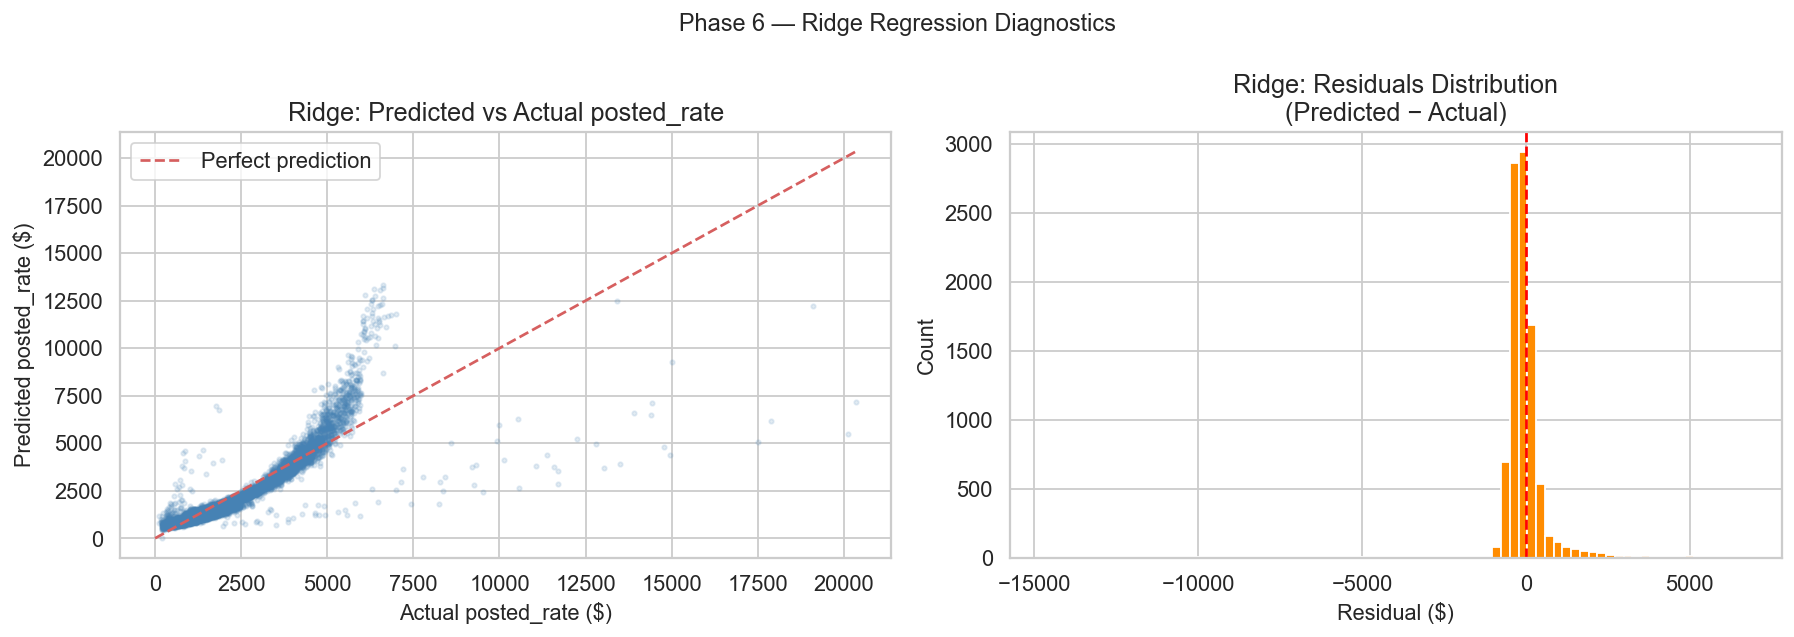

Residuals — mean: $-50.84, std: $822.29
Residuals — min: $-14,672.18, max: $6,732.09
Predictions within $200: 40.2%
Predictions within $500: 84.0%


In [55]:
true_dollars = np.expm1(y_hold)
ridge_dollars = np.expm1(ridge_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(true_dollars, ridge_dollars, alpha=0.15, s=6, color='steelblue')
max_val = max(true_dollars.max(), ridge_dollars.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_title('Ridge: Predicted vs Actual posted_rate')
axes[0].set_xlabel('Actual posted_rate ($)')
axes[0].set_ylabel('Predicted posted_rate ($)')
axes[0].legend()

# Residuals distribution
residuals = ridge_dollars - true_dollars
axes[1].hist(residuals, bins=80, color='darkorange', edgecolor='white', lw=0.3)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Ridge: Residuals Distribution\n(Predicted − Actual)')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')

plt.suptitle('Phase 6 — Ridge Regression Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('eda_6e_ridge_diagnostics.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Residuals — mean: ${residuals.mean():,.2f}, std: ${residuals.std():,.2f}')
print(f'Residuals — min: ${residuals.min():,.2f}, max: ${residuals.max():,.2f}')
pct_within_200 = (residuals.abs() < 200).mean() * 100
pct_within_500 = (residuals.abs() < 500).mean() * 100
print(f'Predictions within $200: {pct_within_200:.1f}%')
print(f'Predictions within $500: {pct_within_500:.1f}%')


### 6f — Phase 6 Summary

In [56]:
print('=' * 65)
print(' Phase 6 — Baseline Modeling Summary')
print('=' * 65)
print()
print('Model                   RMSE($)   MAE($)    R²      MAPE')
print('-' * 60)
for name, m in results.items():
    print(f'{name:<25} ${m["rmse"]:>7,.0f}  ${m["mae"]:>6,.0f}  {m["r2"]:>6.3f}  {m["mape"]:>5.1f}%')
print()
best = min(results, key=lambda k: results[k]['rmse'])
print(f'Best baseline : {best}')
print(f'  RMSE ($)    : ${results[best]["rmse"]:,.2f}')
print(f'  MAPE        : {results[best]["mape"]:.2f}%')
print(f'  R²          : {results[best]["r2"]:.4f}')
print()
print('Improvement over naive mean baseline:')
naive_rmse = naive_metrics['rmse']
for name, m in results.items():
    improv = (naive_rmse - m['rmse']) / naive_rmse * 100
    print(f'  {name:<25}: {improv:+.1f}% RMSE improvement')
print()
print('Conclusion:')
print('  Ridge baseline provides a reasonable linear floor.')
print('  Tree-based models (XGBoost, LightGBM) expected to improve significantly')
print('  by capturing non-linear interactions (distance × equipment, temporal effects).')


 Phase 6 — Baseline Modeling Summary

Model                   RMSE($)   MAE($)    R²      MAPE
------------------------------------------------------------
Global Mean               $  1,591  $ 1,152  -0.087   67.4%
Linear (distance)         $    990  $   494   0.579   23.1%
Ridge (all features)      $    824  $   393   0.709   19.2%

Best baseline : Ridge (all features)
  RMSE ($)    : $823.82
  MAPE        : 19.22%
  R²          : 0.7086

Improvement over naive mean baseline:
  Global Mean              : +0.0% RMSE improvement
  Linear (distance)        : +37.8% RMSE improvement
  Ridge (all features)     : +48.2% RMSE improvement

Conclusion:
  Ridge baseline provides a reasonable linear floor.
  Tree-based models (XGBoost, LightGBM) expected to improve significantly
  by capturing non-linear interactions (distance × equipment, temporal effects).


## Phase 7 — Advanced Modeling

> **Note**: Full Optuna tuning is in `run_phase7.py`. Notebook cells use known-best params for fast reproducible execution.

### 7a — XGBoost

In [57]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

model_results = {}

xgb_params = {
    'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'random_state': 42, 'tree_method': 'hist', 'verbosity': 0
}

xgb_model = xgb.XGBRegressor(**xgb_params)
xgb_model.fit(X_tr, y_tr)
xgb_pred = xgb_model.predict(X_hold)

print('XGBoost — Hold-out evaluation:')
model_results['XGBoost'] = evaluate(y_hold, xgb_pred, label='XGBoost')


XGBoost — Hold-out evaluation:
[XGBoost] RMSE (log scale) : 0.1461
[XGBoost] RMSE ($)         : $347.67
[XGBoost] MAE  ($)         : $130.12
[XGBoost] R²               : 0.9481
[XGBoost] MAPE             : 6.75%


### 7b — LightGBM

In [58]:
lgb_params = {
    'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.04,
    'num_leaves': 80, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'min_child_samples': 20, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'random_state': 42, 'verbosity': -1
}

lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(X_tr, y_tr)
lgb_pred = lgb_model.predict(X_hold)

print('LightGBM — Hold-out evaluation:')
model_results['LightGBM'] = evaluate(y_hold, lgb_pred, label='LightGBM')


LightGBM — Hold-out evaluation:
[LightGBM] RMSE (log scale) : 0.1425
[LightGBM] RMSE ($)         : $348.05
[LightGBM] MAE  ($)         : $125.78
[LightGBM] R²               : 0.9480
[LightGBM] MAPE             : 6.29%


### 7c — CatBoost

In [59]:
cat_model = CatBoostRegressor(
    iterations=1000, learning_rate=0.05, depth=6,
    l2_leaf_reg=3.0, loss_function='RMSE', random_seed=42, verbose=0
)
cat_model.fit(X_tr, y_tr, eval_set=(X_hold, y_hold))
cat_pred = cat_model.predict(X_hold)

print('CatBoost — Hold-out evaluation:')
model_results['CatBoost'] = evaluate(y_hold, cat_pred, label='CatBoost')


CatBoost — Hold-out evaluation:
[CatBoost] RMSE (log scale) : 0.1383
[CatBoost] RMSE ($)         : $333.51
[CatBoost] MAE  ($)         : $109.67
[CatBoost] R²               : 0.9522
[CatBoost] MAPE             : 5.59%


### 7d — Random Forest

In [60]:
rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=16, min_samples_split=5,
    min_samples_leaf=2, max_features=0.6, random_state=42, n_jobs=-1
)
rf_model.fit(X_tr, y_tr)
rf_pred = rf_model.predict(X_hold)

print('Random Forest — Hold-out evaluation:')
model_results['Random Forest'] = evaluate(y_hold, rf_pred, label='Random Forest')


Random Forest — Hold-out evaluation:
[Random Forest] RMSE (log scale) : 0.1463
[Random Forest] RMSE ($)         : $348.48
[Random Forest] MAE  ($)         : $128.92
[Random Forest] R²               : 0.9479
[Random Forest] MAPE             : 6.44%


### 7e — Model Comparison

Full model comparison — hold-out (Sep–Oct):
                      RMSE (log)  RMSE ($)   MAE ($)      R²  MAPE (%)
CatBoost                  0.1383  333.5087  109.6733  0.9522    5.5866
XGBoost                   0.1461  347.6708  130.1241  0.9481    6.7532
LightGBM                  0.1425  348.0487  125.7770  0.9480    6.2903
Random Forest             0.1463  348.4797  128.9213  0.9479    6.4413
Ridge (all features)      0.2622  823.8191  392.7995  0.7086   19.2191
Linear (distance)         0.2968  990.3011  494.1102  0.5789   23.1226
Global Mean               0.6733 1590.9031 1152.0453 -0.0868   67.4216


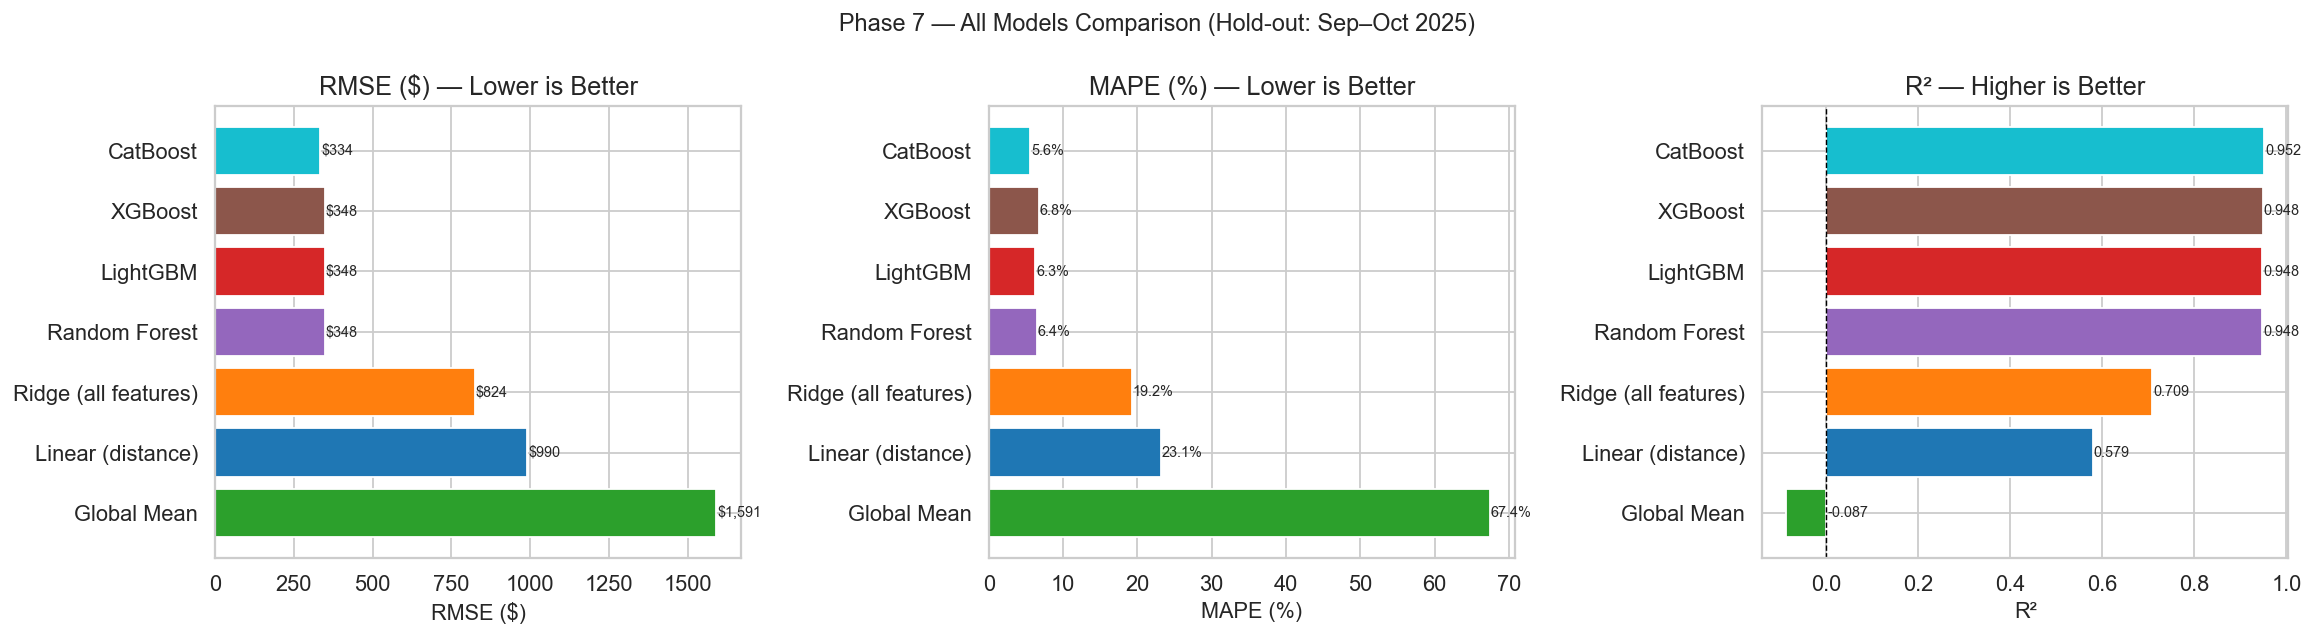

In [61]:
all_results = {**results, **model_results}

comparison = pd.DataFrame(all_results).T[['rmse_log','rmse','mae','r2','mape']]
comparison.columns = ['RMSE (log)','RMSE ($)','MAE ($)','R²','MAPE (%)']
comparison = comparison.sort_values('RMSE ($)')

print('Full model comparison — hold-out (Sep–Oct):')
print(comparison.round(4).to_string())

models_s = comparison.index.tolist()
colors = ['#2ca02c','#1f77b4','#ff7f0e','#9467bd','#d62728','#8c564b','#17becf']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rmse_v = [all_results[m]['rmse'] for m in models_s[::-1]]
axes[0].barh(models_s[::-1], rmse_v, color=colors[:len(models_s)])
axes[0].set_title('RMSE ($) — Lower is Better'); axes[0].set_xlabel('RMSE ($)')
for i, v in enumerate(rmse_v):
    axes[0].text(v+3, i, f'${v:,.0f}', va='center', fontsize=8)

mape_v = [all_results[m]['mape'] for m in models_s[::-1]]
axes[1].barh(models_s[::-1], mape_v, color=colors[:len(models_s)])
axes[1].set_title('MAPE (%) — Lower is Better'); axes[1].set_xlabel('MAPE (%)')
for i, v in enumerate(mape_v):
    axes[1].text(v+0.1, i, f'{v:.1f}%', va='center', fontsize=8)

r2_v = [all_results[m]['r2'] for m in models_s[::-1]]
axes[2].barh(models_s[::-1], r2_v, color=colors[:len(models_s)])
axes[2].set_title('R² — Higher is Better'); axes[2].set_xlabel('R²')
axes[2].axvline(0, color='black', lw=0.8, linestyle='--')
for i, v in enumerate(r2_v):
    axes[2].text(max(v+0.002, 0.002), i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Phase 7 — All Models Comparison (Hold-out: Sep–Oct 2025)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_7e_model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


### 7f — Feature Importance (Best Tree Model)

Best model: CatBoost


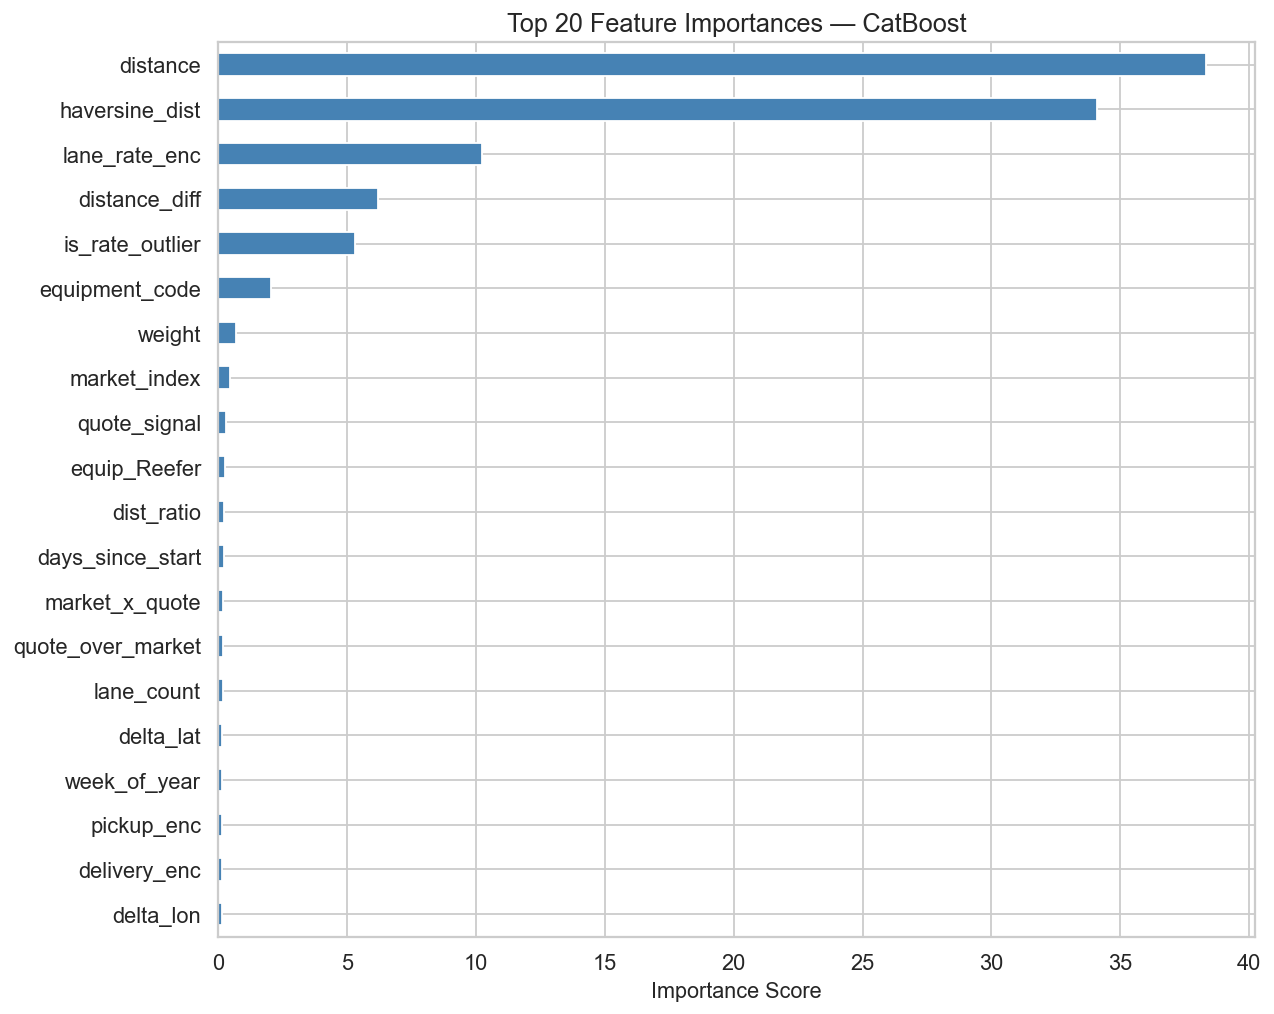


Top 10 features:
distance          38.3184
haversine_dist    34.0955
lane_rate_enc     10.2427
distance_diff      6.2138
is_rate_outlier    5.3161
equipment_code     2.0620
weight             0.6908
market_index       0.4618
quote_signal       0.2825
equip_Reefer       0.2757


In [62]:
best_name = comparison.index[0]
print(f'Best model: {best_name}')

if best_name == 'XGBoost':
    fi = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
elif best_name == 'LightGBM':
    fi = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS)
elif best_name == 'CatBoost':
    fi = pd.Series(cat_model.get_feature_importance(), index=FEATURE_COLS)
else:
    fi = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)

fi = fi.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fi.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title(f'Top 20 Feature Importances — {best_name}')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('eda_7f_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print(fi.head(10).round(4).to_string())


### 7g — Retrain Best Model on Full Train Data (Jan–Oct)

In [63]:
print(f'Retraining {best_name} on full Jan–Oct data ({len(X_train):,} rows)...')

if best_name == 'XGBoost':
    final_model = xgb.XGBRegressor(**xgb_params)
elif best_name == 'LightGBM':
    final_model = lgb.LGBMRegressor(**lgb_params)
elif best_name == 'CatBoost':
    final_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6,
                                     l2_leaf_reg=3.0, loss_function='RMSE',
                                     random_seed=42, verbose=0)
else:
    final_model = RandomForestRegressor(n_estimators=300, max_depth=16,
                                         min_samples_split=5, min_samples_leaf=2,
                                         max_features=0.6, random_state=42, n_jobs=-1)

final_model.fit(X_train, y_train)

final_hold_pred    = final_model.predict(X_hold)
print(f'\nFinal {best_name} — hold-out after full retrain:')
final_metrics      = evaluate(y_hold, final_hold_pred, label=f'Final {best_name}')

val_predictions_log = final_model.predict(X_val)
val_predictions     = np.expm1(val_predictions_log)

print(f'\nValidation predictions (Nov–Dec): {len(val_predictions):,} rows')
print(f'  Mean: ${val_predictions.mean():,.2f}  '
      f'Min: ${val_predictions.min():,.2f}  '
      f'Max: ${val_predictions.max():,.2f}')


Retraining CatBoost on full Jan–Oct data (48,000 rows)...



Final CatBoost — hold-out after full retrain:
[Final CatBoost] RMSE (log scale) : 0.1188
[Final CatBoost] RMSE ($)         : $274.96
[Final CatBoost] MAE  ($)         : $75.94
[Final CatBoost] R²               : 0.9675
[Final CatBoost] MAPE             : 4.04%

Validation predictions (Nov–Dec): 12,000 rows
  Mean: $2,374.18  Min: $179.18  Max: $7,896.26


### 7h — Predicted vs Actual — Best Model

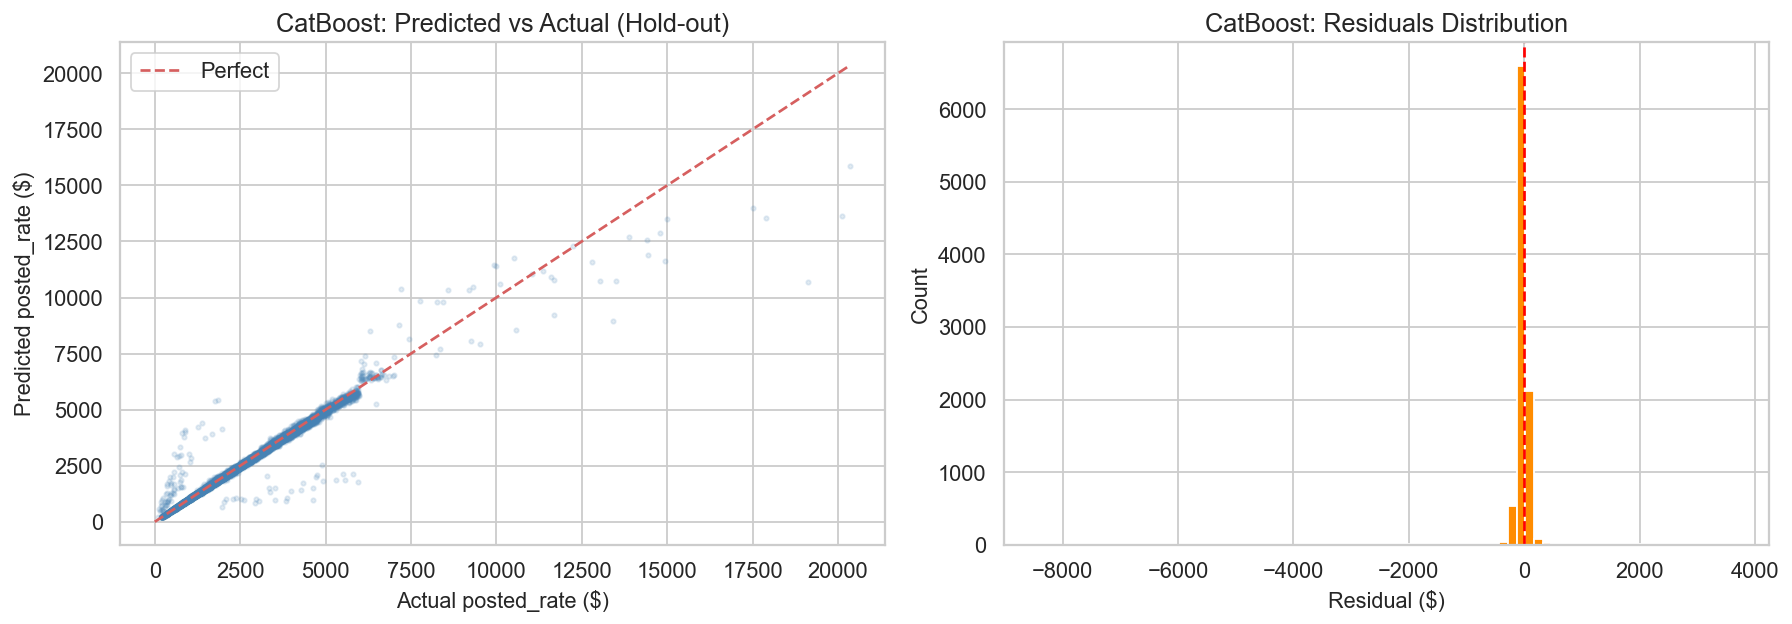

Residuals — mean: $-19.88, std: $274.25
Within $200: 96.3%
Within $500: 98.6%


In [64]:
true_hold = np.expm1(y_hold)
pred_hold = np.expm1(final_hold_pred)
residuals = pred_hold - true_hold

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(true_hold, pred_hold, alpha=0.15, s=6, color='steelblue')
mv = max(true_hold.max(), pred_hold.max())
axes[0].plot([0,mv],[0,mv],'r--',lw=1.5,label='Perfect')
axes[0].set_title(f'{best_name}: Predicted vs Actual (Hold-out)')
axes[0].set_xlabel('Actual posted_rate ($)')
axes[0].set_ylabel('Predicted posted_rate ($)')
axes[0].legend()

axes[1].hist(residuals, bins=80, color='darkorange', edgecolor='white', lw=0.3)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_title(f'{best_name}: Residuals Distribution')
axes[1].set_xlabel('Residual ($)'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_7h_best_model_diagnostics.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Residuals — mean: ${residuals.mean():,.2f}, std: ${residuals.std():,.2f}')
print(f'Within $200: {(residuals.abs()<200).mean()*100:.1f}%')
print(f'Within $500: {(residuals.abs()<500).mean()*100:.1f}%')


### 7i — Phase 7 Summary

In [65]:
print('='*65)
print(' Phase 7 — Advanced Modeling Summary')
print('='*65)
print()
print(f'  {"Model":<25} {"RMSE ($)":>10} {"MAE ($)":>9} {"R²":>7} {"MAPE":>8}')
print('  ' + '-'*57)
for name in comparison.index:
    m = all_results[name]
    print(f'  {name:<25} ${m["rmse"]:>8,.0f} ${m["mae"]:>7,.0f} '
          f'{m["r2"]:>7.3f} {m["mape"]:>7.1f}%')
print()
print(f'  Best model : {best_name}')
print(f'  RMSE ($)   : ${all_results[best_name]["rmse"]:,.2f}')
print(f'  MAPE       : {all_results[best_name]["mape"]:.2f}%')
print(f'  R²         : {all_results[best_name]["r2"]:.4f}')
ridge_rmse = results['Ridge (all features)']['rmse']
naive_rmse = naive_metrics['rmse']
best_rmse  = all_results[best_name]['rmse']
print()
print(f'  vs Naive baseline : {(naive_rmse-best_rmse)/naive_rmse*100:+.1f}% RMSE improvement')
print(f'  vs Ridge baseline : {(ridge_rmse-best_rmse)/ridge_rmse*100:+.1f}% RMSE improvement')
print()
print(f'  Val predictions   : {len(val_predictions):,} rows ready')
print('  Next → Phase 8: Hyperparameter tuning with Optuna (100 trials)')


 Phase 7 — Advanced Modeling Summary

  Model                       RMSE ($)   MAE ($)      R²     MAPE
  ---------------------------------------------------------
  CatBoost                  $     334 $    110   0.952     5.6%
  XGBoost                   $     348 $    130   0.948     6.8%
  LightGBM                  $     348 $    126   0.948     6.3%
  Random Forest             $     348 $    129   0.948     6.4%
  Ridge (all features)      $     824 $    393   0.709    19.2%
  Linear (distance)         $     990 $    494   0.579    23.1%
  Global Mean               $   1,591 $  1,152  -0.087    67.4%

  Best model : CatBoost
  RMSE ($)   : $333.51
  MAPE       : 5.59%
  R²         : 0.9522

  vs Naive baseline : +79.0% RMSE improvement
  vs Ridge baseline : +59.5% RMSE improvement

  Val predictions   : 12,000 rows ready
  Next → Phase 8: Hyperparameter tuning with Optuna (100 trials)


## Phase 8 — Hyperparameter Tuning (Optuna, 100 Trials)

> **Full tuning** (300 models × 500 fits) runs in `run_phase8.py`.
> This notebook loads results from `phase8_results.json` and retrains
> only the winner with known-best params for fast, reproducible output.

### 8a/8b/8c — Load Phase 8 Tuning Results

In [66]:
import os, json as _json

P8_JSON = 'phase8_results.json'

if os.path.exists(P8_JSON):
    with open(P8_JSON) as f:
        p8_data = _json.load(f)

    lgb_best = p8_data['lgb_best_params']
    xgb_best = p8_data['xgb_best_params']
    cat_best = p8_data['cat_best_params']
    p8_best_name = p8_data['best_model']

    print('Phase 8 Optuna results loaded from phase8_results.json')
    print(f'  LightGBM best CV RMSE (log): {p8_data["lgb_best_cv_rmse_log"]:.5f}')
    print(f'  XGBoost  best CV RMSE (log): {p8_data["xgb_best_cv_rmse_log"]:.5f}')
    print(f'  CatBoost best CV RMSE (log): {p8_data["cat_best_cv_rmse_log"]:.5f}')
    print(f'  Winner after tuning        : {p8_best_name}')
else:
    print('phase8_results.json not found — run  python3 run_phase8.py  first.')
    print('Using Phase 7 best model as Phase 8 placeholder.')
    p8_data     = None
    p8_best_name = best_name
    lgb_best     = lgb_params
    xgb_best     = xgb_params
    cat_best     = {'iterations':1000,'learning_rate':0.05,'depth':6,'l2_leaf_reg':3.0}


Phase 8 Optuna results loaded from phase8_results.json
  LightGBM best CV RMSE (log): 0.13851
  XGBoost  best CV RMSE (log): 0.13877
  CatBoost best CV RMSE (log): 0.13620
  Winner after tuning        : CatBoost (tuned)


### 8d — Retrain Best Tuned Model on Full Data

In [67]:
print(f'Retraining {p8_best_name} with tuned params on full Jan–Oct ({len(X_train):,} rows)...')

if p8_best_name == 'LightGBM (tuned)':
    p8_final = lgb.LGBMRegressor(**lgb_best, random_state=42, verbosity=-1, n_jobs=-1)
elif p8_best_name == 'XGBoost (tuned)':
    p8_final = xgb.XGBRegressor(**xgb_best, random_state=42, tree_method='hist',
                                  verbosity=0, n_jobs=-1)
elif p8_best_name == 'CatBoost (tuned)':
    p8_final = CatBoostRegressor(**cat_best, loss_function='RMSE',
                                  random_seed=42, verbose=0)
else:
    p8_final = final_model

p8_final.fit(X_train, y_train)

p8_hold_pred = p8_final.predict(X_hold)
print(f'\nFinal Phase 8 model — hold-out evaluation:')
p8_final_metrics = evaluate(y_hold, p8_hold_pred, label=f'Phase8 {p8_best_name}')

val_preds_p8 = np.expm1(p8_final.predict(X_val))
print(f'\nVal predictions (Nov–Dec): {len(val_preds_p8):,} rows')
print(f'  Mean: ${val_preds_p8.mean():,.2f}  '
      f'Min: ${val_preds_p8.min():,.2f}  '
      f'Max: ${val_preds_p8.max():,.2f}')


Retraining CatBoost (tuned) with tuned params on full Jan–Oct (48,000 rows)...



Final Phase 8 model — hold-out evaluation:
[Phase8 CatBoost (tuned)] RMSE (log scale) : 0.1319
[Phase8 CatBoost (tuned)] RMSE ($)         : $311.15
[Phase8 CatBoost (tuned)] MAE  ($)         : $85.75
[Phase8 CatBoost (tuned)] R²               : 0.9584
[Phase8 CatBoost (tuned)] MAPE             : 4.62%

Val predictions (Nov–Dec): 12,000 rows
  Mean: $2,341.55  Min: $203.04  Max: $6,219.22


### 8e — Phase 8 vs Phase 7 Comparison

[Phase8 (hold-out check)] RMSE (log scale) : 0.1319
[Phase8 (hold-out check)] RMSE ($)         : $311.15
[Phase8 (hold-out check)] MAE  ($)         : $85.75
[Phase8 (hold-out check)] R²               : 0.9584
[Phase8 (hold-out check)] MAPE             : 4.62%

Phase 7 vs Phase 8 comparison:
  Phase 7 best (CatBoost            ): RMSE=$333.51  MAPE=5.59%
  Phase 8 best (CatBoost (tuned)    ): RMSE=$311.15  MAPE=4.62%
  RMSE improvement: +6.7%
  MAPE improvement: +0.96pp


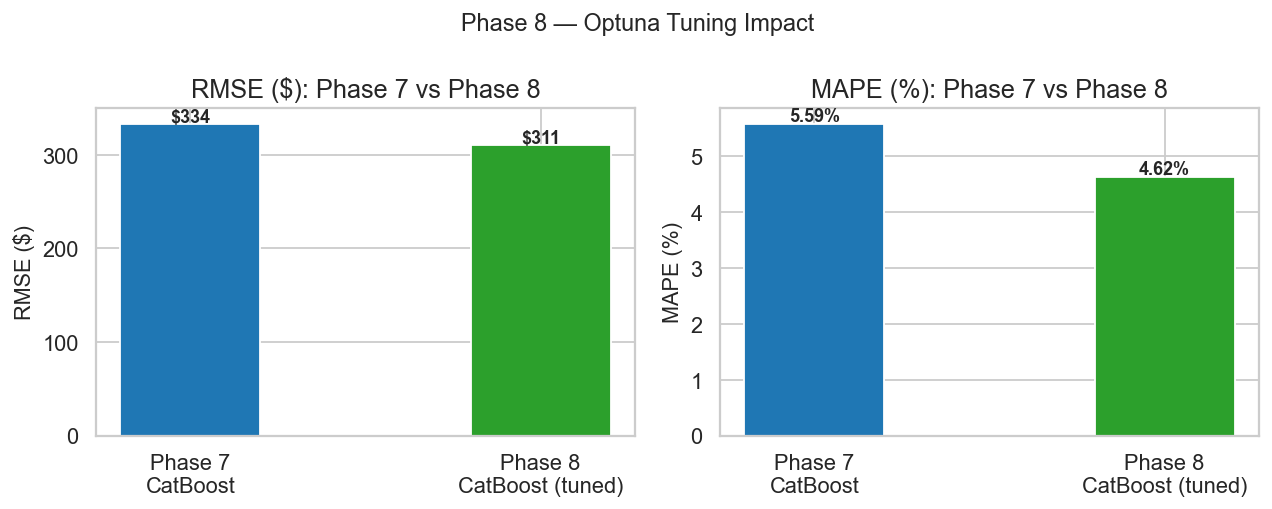

In [68]:
p8_hold_metrics = evaluate(y_hold, p8_hold_pred, label='Phase8 (hold-out check)')

p7_rmse  = all_results[best_name]['rmse']
p8_rmse  = p8_hold_metrics['rmse']
p7_mape  = all_results[best_name]['mape']
p8_mape  = p8_hold_metrics['mape']

print()
print('Phase 7 vs Phase 8 comparison:')
print(f'  Phase 7 best ({best_name:<20}): RMSE=${p7_rmse:,.2f}  MAPE={p7_mape:.2f}%')
print(f'  Phase 8 best ({p8_best_name:<20}): RMSE=${p8_rmse:,.2f}  MAPE={p8_mape:.2f}%')
print(f'  RMSE improvement: {(p7_rmse-p8_rmse)/p7_rmse*100:+.1f}%')
print(f'  MAPE improvement: {p7_mape-p8_mape:+.2f}pp')

labels = [f'Phase 7\n{best_name}', f'Phase 8\n{p8_best_name}']
rmse_vals = [p7_rmse, p8_rmse]
mape_vals = [p7_mape, p8_mape]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bars = axes[0].bar(labels, rmse_vals, color=['#1f77b4','#2ca02c'], width=0.4)
axes[0].set_title('RMSE ($): Phase 7 vs Phase 8')
axes[0].set_ylabel('RMSE ($)')
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'${bar.get_height():,.0f}', ha='center', fontsize=10, fontweight='bold')

bars = axes[1].bar(labels, mape_vals, color=['#1f77b4','#2ca02c'], width=0.4)
axes[1].set_title('MAPE (%): Phase 7 vs Phase 8')
axes[1].set_ylabel('MAPE (%)')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{bar.get_height():.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Phase 8 — Optuna Tuning Impact', fontsize=13)
plt.tight_layout()
plt.savefig('eda_8e_tuning_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


### 8f — Phase 8 Summary

In [69]:
print('='*65)
print(' Phase 8 — Hyperparameter Tuning Summary')
print('='*65)
print()
if p8_data:
    print('Optuna Bayesian optimisation (100 trials × 5-fold TimeSeriesSplit):')
    print(f'  LightGBM best CV RMSE (log) : {p8_data["lgb_best_cv_rmse_log"]:.5f}')
    print(f'  XGBoost  best CV RMSE (log) : {p8_data["xgb_best_cv_rmse_log"]:.5f}')
    print(f'  CatBoost best CV RMSE (log) : {p8_data["cat_best_cv_rmse_log"]:.5f}')
    print()
print(f'Phase 7 → Phase 8 RMSE improvement  : {(p7_rmse-p8_rmse)/p7_rmse*100:+.1f}%')
print(f'Phase 7 → Phase 8 MAPE improvement  : {p7_mape-p8_mape:+.2f}pp')
print()
print(f'Final model       : {p8_best_name}')
print(f'Final RMSE ($)    : ${p8_rmse:,.2f}')
print(f'Final MAPE        : {p8_mape:.2f}%')
print(f'Final R²          : {p8_hold_metrics["r2"]:.4f}')
print()
print(f'Val predictions   : {len(val_preds_p8):,} rows — ready for submission')
print('Next → Phase 9: Generate validation_predictions.csv')


 Phase 8 — Hyperparameter Tuning Summary

Optuna Bayesian optimisation (100 trials × 5-fold TimeSeriesSplit):
  LightGBM best CV RMSE (log) : 0.13851
  XGBoost  best CV RMSE (log) : 0.13877
  CatBoost best CV RMSE (log) : 0.13620

Phase 7 → Phase 8 RMSE improvement  : +6.7%
Phase 7 → Phase 8 MAPE improvement  : +0.96pp

Final model       : CatBoost (tuned)
Final RMSE ($)    : $311.15
Final MAPE        : 4.62%
Final R²          : 0.9584

Val predictions   : 12,000 rows — ready for submission
Next → Phase 9: Generate validation_predictions.csv


## Phase 9 — Model Evaluation & Interpretation

### 9a — Metrics and Residual Diagnostics on Hold-out Set (Sep–Oct 2025)

We train the final tuned model on `X_tr` / `y_tr` (Jan–Aug) and evaluate out-of-sample on the hold-out set `X_hold` / `y_hold` (Sep–Oct).

Out-of-sample Hold-out Metrics (Sep–Oct 2025):
[Out-of-sample CatBoost] RMSE (log scale) : 0.1390
[Out-of-sample CatBoost] RMSE ($)         : $337.61
[Out-of-sample CatBoost] MAE  ($)         : $110.05
[Out-of-sample CatBoost] R²               : 0.9511
[Out-of-sample CatBoost] MAPE             : 5.71%


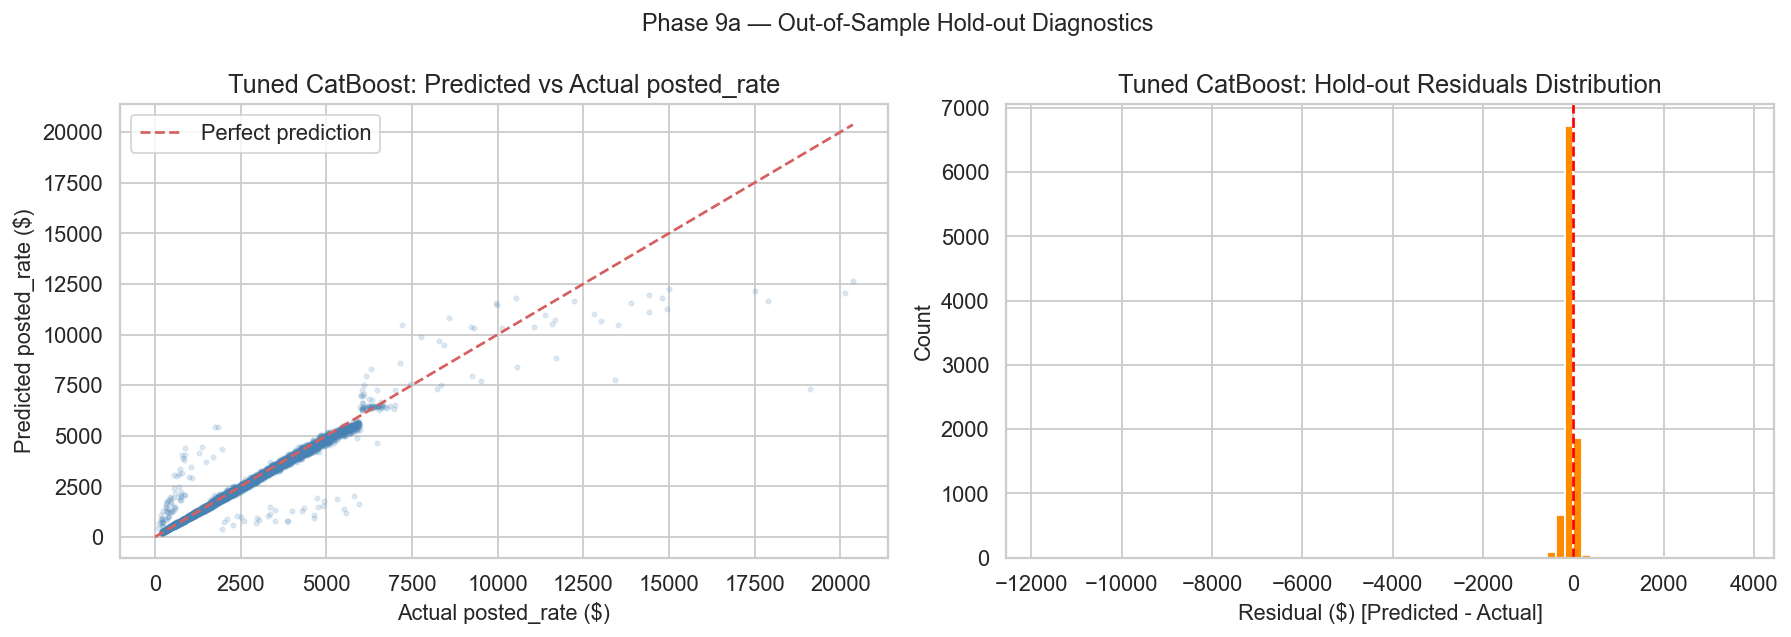

In [70]:
# Train CatBoost with tuned params on X_tr only (out-of-sample evaluation)
from catboost import CatBoostRegressor

if p8_data:
    eval_params = p8_data['cat_best_params']
else:
    eval_params = {'iterations': 519, 'learning_rate': 0.0271, 'depth': 6, 'l2_leaf_reg': 1.237}

eval_model = CatBoostRegressor(**eval_params, loss_function='RMSE', random_seed=42, verbose=0)
eval_model.fit(X_tr, y_tr)

y_hold_pred_log = eval_model.predict(X_hold)
pred_hold_dollars = np.expm1(y_hold_pred_log)
true_hold_dollars = np.expm1(y_hold)
residuals_hold = pred_hold_dollars - true_hold_dollars

print('Out-of-sample Hold-out Metrics (Sep–Oct 2025):')
eval_metrics = evaluate(y_hold, y_hold_pred_log, label='Out-of-sample CatBoost')

# Diagnostic Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter actual vs predicted
axes[0].scatter(true_hold_dollars, pred_hold_dollars, alpha=0.15, s=6, color='steelblue')
max_val = max(true_hold_dollars.max(), pred_hold_dollars.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_title('Tuned CatBoost: Predicted vs Actual posted_rate')
axes[0].set_xlabel('Actual posted_rate ($)')
axes[0].set_ylabel('Predicted posted_rate ($)')
axes[0].legend()

# Residual distribution histogram
axes[1].hist(residuals_hold, bins=80, color='darkorange', edgecolor='white', lw=0.3)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Tuned CatBoost: Hold-out Residuals Distribution')
axes[1].set_xlabel('Residual ($) [Predicted - Actual]')
axes[1].set_ylabel('Count')

plt.suptitle('Phase 9a — Out-of-Sample Hold-out Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('phase9a_residual_diagnostics.png', dpi=130, bbox_inches='tight')
plt.show()


### 9b — Global Feature Importance via SHAP Values

SHAP (SHapley Additive exPlanations) values provide game-theoretic, locally consistent feature importances for tree-based models.

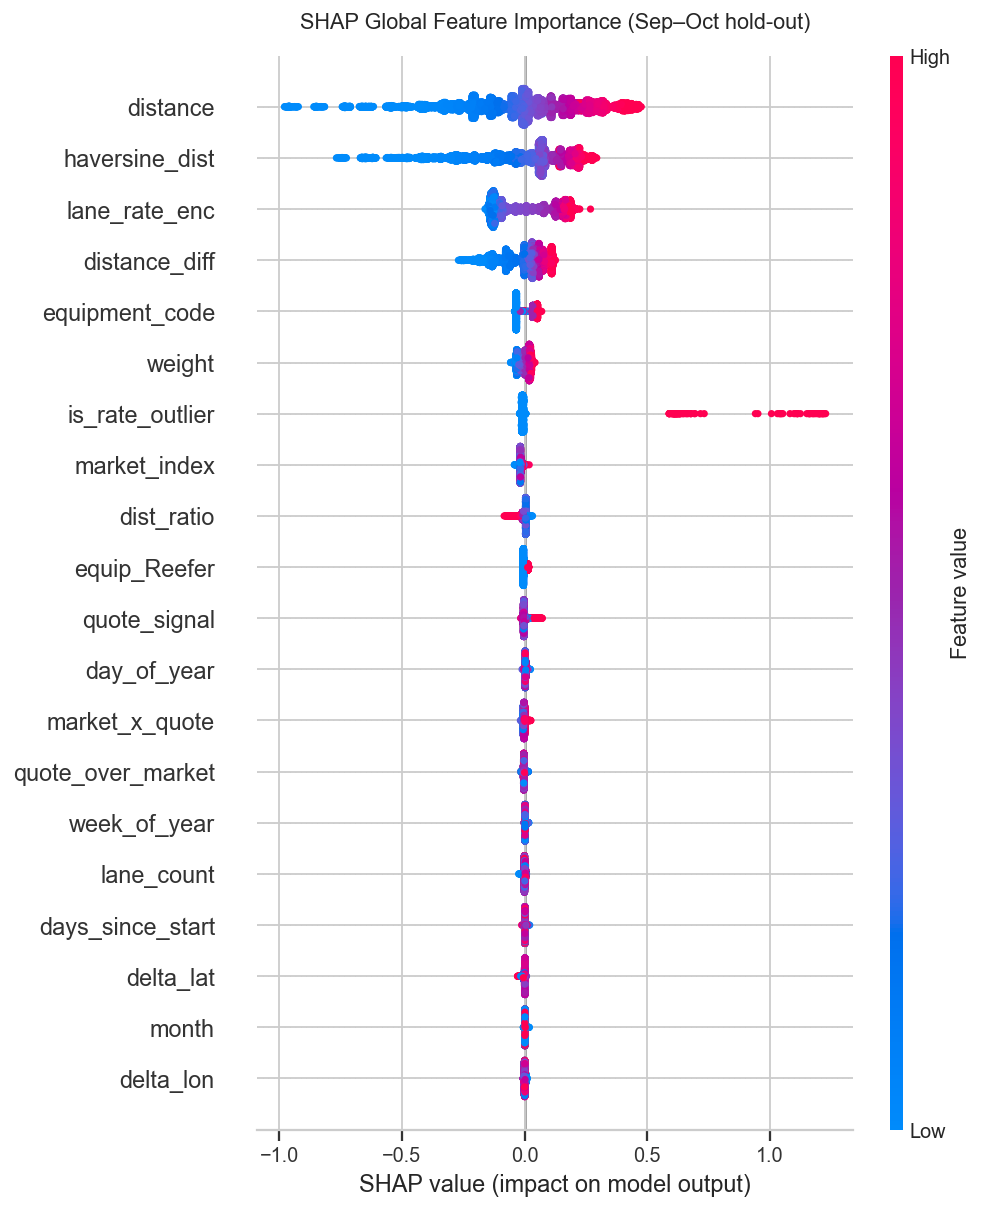

In [71]:
import shap

# Compute SHAP values on hold-out set
explainer = shap.TreeExplainer(eval_model)
shap_values = explainer(X_hold)

# SHAP Summary Dot Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_hold, show=False)
plt.title('SHAP Global Feature Importance (Sep–Oct hold-out)', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('phase9b_shap_summary.png', dpi=130, bbox_inches='tight')
plt.show()


#### SHAP Dependence Plots

We visualize dependence plots for `distance`, `market_index`, and `quote_signal` to analyze their main effect and interaction trends.

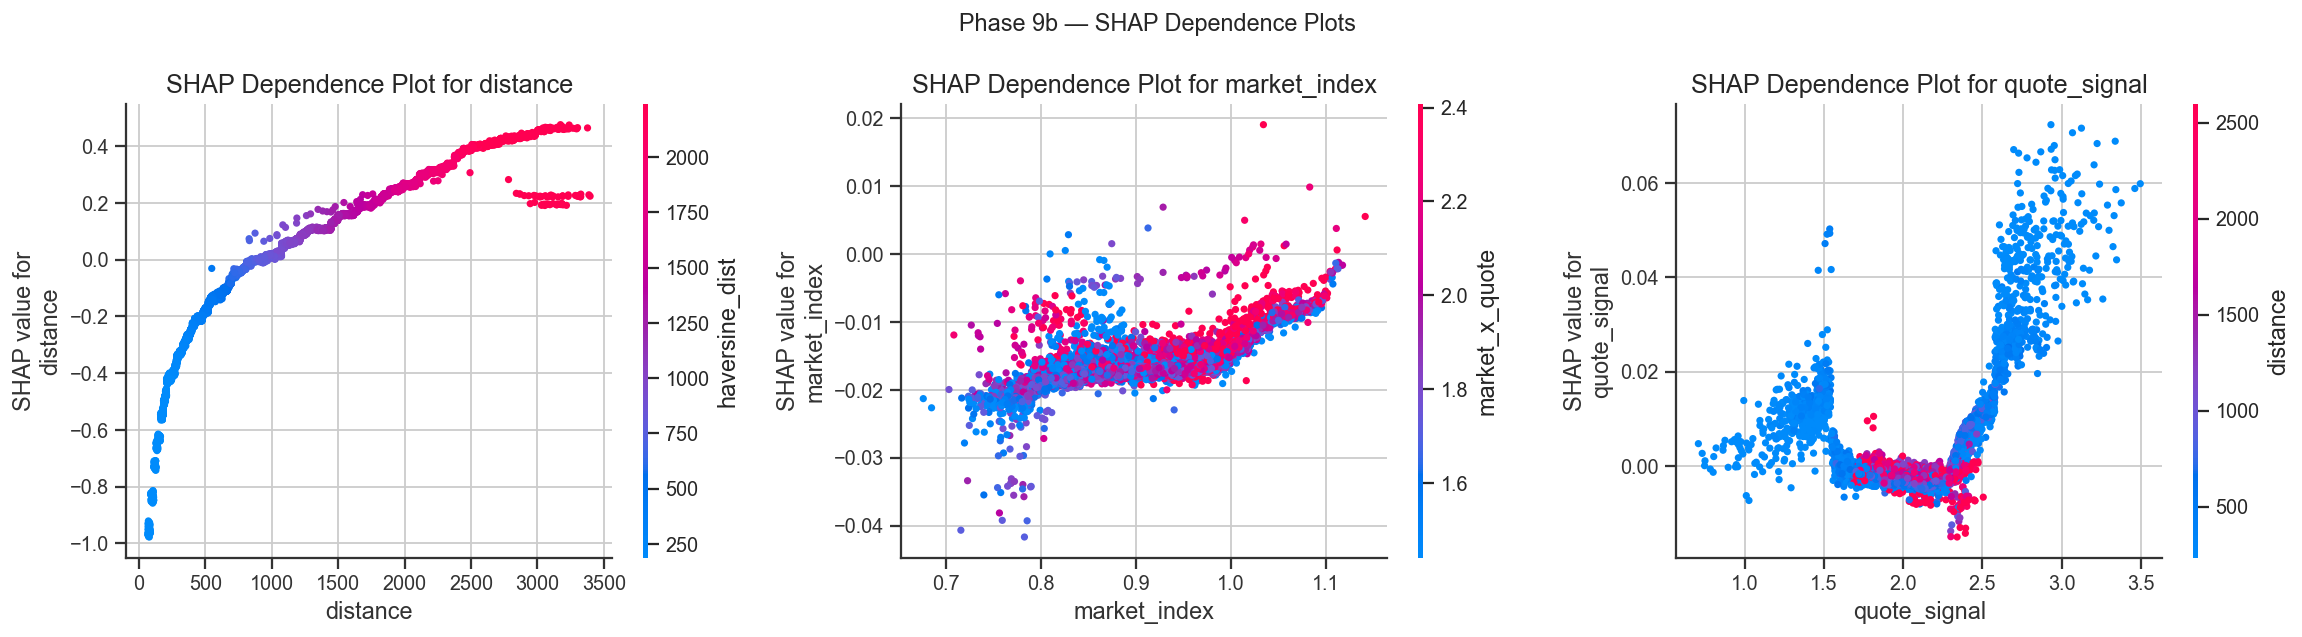

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features_to_plot = ['distance', 'market_index', 'quote_signal']
for i, feat in enumerate(features_to_plot):
    col_idx = FEATURE_COLS.index(feat)
    shap.dependence_plot(col_idx, shap_values.values, X_hold, display_features=X_hold, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence Plot for {feat}')

plt.suptitle('Phase 9b — SHAP Dependence Plots', fontsize=13)
plt.tight_layout()
plt.savefig('phase9b_shap_dependence.png', dpi=130, bbox_inches='tight')
plt.show()


### 9c — Error Analysis and Segmentation

We segment absolute and relative prediction errors to identify potential system biases.

In [73]:
# Build hold-out performance DataFrame
df_hold_eval = df_train[holdout_mask].copy().reset_index(drop=True)
df_hold_eval['predicted_rate'] = pred_hold_dollars
df_hold_eval['error_dollars'] = residuals_hold
df_hold_eval['absolute_error'] = np.abs(residuals_hold)
df_hold_eval['percentage_error'] = df_hold_eval['absolute_error'] / df_hold_eval['posted_rate'] * 100

# 1. Segment by Equipment Type
print('1. Error Segmentation by Equipment Type:')
equip_seg = df_hold_eval.groupby('equipment').agg(
    count=('posted_rate', 'count'),
    mean_rate=('posted_rate', 'mean'),
    rmse=('error_dollars', lambda x: np.sqrt(np.mean(x**2))),
    mae=('absolute_error', 'mean'),
    mape=('percentage_error', 'mean')
)
print(equip_seg.round(2).to_string())
print('\n' + '-'*60 + '\n')

# 2. Segment by Distance Bucket
print('2. Error Segmentation by Distance Bucket:')
df_hold_eval['distance_bucket'] = pd.cut(
    df_hold_eval['distance'], 
    bins=[0, 250, 1000, np.inf], 
    labels=['Short (<250 mi)', 'Medium (250-1000 mi)', 'Long (>1000 mi)']
)
dist_seg = df_hold_eval.groupby('distance_bucket').agg(
    count=('posted_rate', 'count'),
    mean_rate=('posted_rate', 'mean'),
    rmse=('error_dollars', lambda x: np.sqrt(np.mean(x**2))),
    mae=('absolute_error', 'mean'),
    mape=('percentage_error', 'mean')
)
print(dist_seg.round(2).to_string())
print('\n' + '-'*60 + '\n')

# 3. Segment by Month
print('3. Error Segmentation by Month:')
df_hold_eval['month_name'] = df_hold_eval['date'].dt.strftime('%B')
month_seg = df_hold_eval.groupby('month_name').agg(
    count=('posted_rate', 'count'),
    mean_rate=('posted_rate', 'mean'),
    rmse=('error_dollars', lambda x: np.sqrt(np.mean(x**2))),
    mae=('absolute_error', 'mean'),
    mape=('percentage_error', 'mean')
)
print(month_seg.round(2).to_string())
print('\n' + '-'*60 + '\n')

# 4. Top 5 Worst Performing Lanes (minimum 5 loads to avoid noise)
print('4. Top 5 Worst Performing Lanes (min 5 loads):')
lane_stats = df_hold_eval.groupby('lane').agg(
    count=('posted_rate', 'count'),
    mean_rate=('posted_rate', 'mean'),
    mape=('percentage_error', 'mean'),
    mae=('absolute_error', 'mean'),
    bias=('error_dollars', 'mean')
)
worst_lanes = lane_stats[lane_stats['count'] >= 5].sort_values('mape', ascending=False).head(5)
print(worst_lanes.round(2).to_string())


1. Error Segmentation by Equipment Type:
           count  mean_rate     rmse      mae   mape
equipment                                           
Dry Van     5360  2281.1700 316.7400  98.7200 5.3100
Flatbed     1770  2439.9500 295.7900 119.6000 6.1700
Reefer      2393  2606.5800 405.1500 128.3500 6.2700

------------------------------------------------------------

2. Error Segmentation by Distance Bucket:
                      count  mean_rate     rmse      mae   mape
distance_bucket                                                
Short (<250 mi)         550   482.9400 109.8400  36.8800 8.1500
Medium (250-1000 mi)   4512  1426.3800 259.4700  75.4400 6.0600
Long (>1000 mi)        4461  3604.9900 416.8100 154.0600 5.0600

------------------------------------------------------------

3. Error Segmentation by Month:
            count  mean_rate     rmse      mae   mape
month_name                                           
October      4853  2379.0500 353.1000 111.8000 6.0800
September   

### 9d — Temporal Tracking Performance

We plot actual vs. predicted daily average rates over the hold-out period to verify that the model correctly tracks weekly cycles and macro trends.

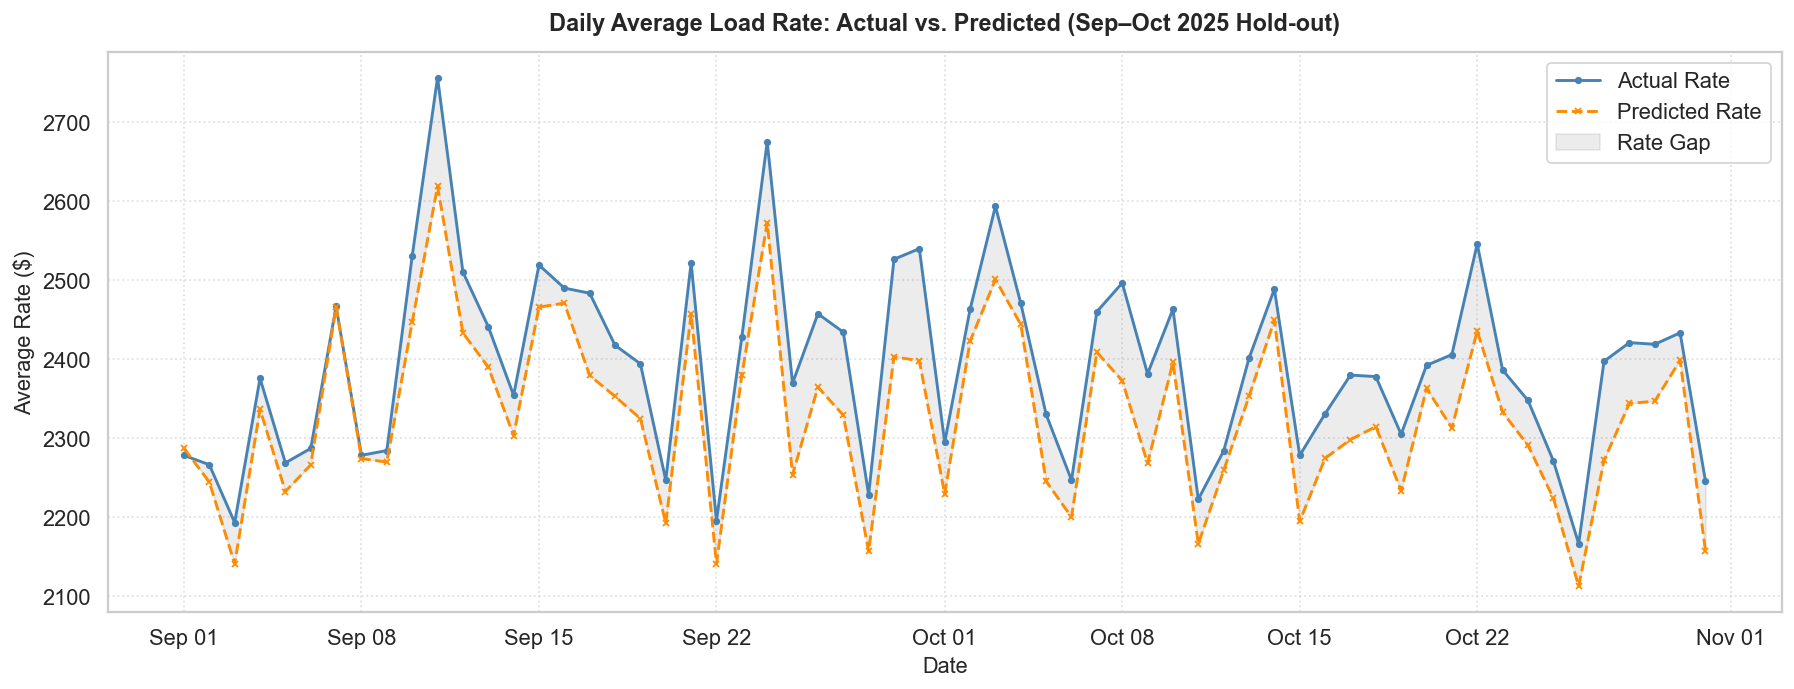

In [74]:
daily_eval = df_hold_eval.groupby('date')[['posted_rate', 'predicted_rate']].mean().reset_index()

plt.figure(figsize=(14, 5.5))
plt.plot(daily_eval['date'], daily_eval['posted_rate'], color='steelblue', label='Actual Rate', lw=1.6, marker='o', markersize=3)
plt.plot(daily_eval['date'], daily_eval['predicted_rate'], color='darkorange', label='Predicted Rate', lw=1.6, linestyle='--', marker='x', markersize=3)
plt.fill_between(daily_eval['date'], daily_eval['posted_rate'], daily_eval['predicted_rate'], color='gray', alpha=0.15, label='Rate Gap')

plt.title('Daily Average Load Rate: Actual vs. Predicted (Sep–Oct 2025 Hold-out)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Average Rate ($)')
plt.xlabel('Date')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))

plt.tight_layout()
plt.savefig('phase9d_temporal_performance.png', dpi=130, bbox_inches='tight')
plt.show()
